<a href="https://colab.research.google.com/github/LulutheBA/ANLOK-WATER-PREDICTION-PROJECT-/blob/main/NB4_Production.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ANLOK Water Prediction Project — Notebook 4
## Production ML Modelling, Feature Selection, Validation, Tuning & Evaluation

**Pipeline:** Notebook 2 → Notebook 3 → **Notebook 4** → Notebook 5

This notebook is a continuation of the ANLOK project. It consumes the repository outputs produced by Notebook 2 and Notebook 3 and writes all Notebook 4 artefacts back into the same project.

### Target integrity decision

The current project does **not** contain a verified event-level historical water-outage target such as outage events, outage frequency, outage duration, previous outage, or days since previous outage. The existing project does contain an explicit **population reliable water-supply percentage** in the Water Supply Reliability dataset.

Accordingly, Notebook 4 models **water-service reliability** and derives an **outage-risk proxy = 100 − predicted reliable-supply percentage**. It does **not** claim to predict actual outage events.

The repository also contains daily weather data and engineered rainfall features. Those features are not blindly merged into the reliability snapshot because the current project does not provide a validated municipality/date key linking each daily weather observation to a reliability target observation. Fabricating that join would be methodologically unsound.

## Why this version is different from the previous Notebook 4

The previous Notebook 4 treated `rainfall_7day` as the target. That answers a rainfall prediction problem, not the ANLOK water-service problem.

This version instead:
- audits the actual project outputs;
- detects whether a true outage target exists;
- uses the project's reliable-supply percentage as the strongest defensible proxy target;
- uses only features available in the project;
- prevents target leakage;
- compares multiple regression models;
- performs cross-validation and tuning on training data only;
- evaluates once on an untouched test set;
- performs a municipality/geographic experiment;
- saves reproducible artefacts and a machine-readable summary;
- prepares evidence directly useful for the CSIT judging criteria.

In [55]:
# ============================================================
# 1. IMPORTS AND REPRODUCIBILITY
# ============================================================

import os
import sys
import glob
import json
import shutil
import subprocess
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")
print("Random state:", RANDOM_STATE)

Libraries imported successfully.
Random state: 42


In [56]:
# ============================================================
# 2. PROJECT CONFIGURATION
# ============================================================

PROJECT_ROOT = "/content/ANLOK-WATER-PREDICTION-PROJECT-"
GITHUB_REPO_URL = "https://github.com/LulutheBA/ANLOK-WATER-PREDICTION-PROJECT-.git"

CLEAN_DATA_DIR = os.path.join(PROJECT_ROOT, "Outputs", "CleanData")
DATA_CLEANING_DIR = os.path.join(PROJECT_ROOT, "Outputs", "DataCleaning")
EDA_DIR = os.path.join(PROJECT_ROOT, "Outputs", "EDA")
FEATURE_ENGINEERING_DIR = os.path.join(PROJECT_ROOT, "Outputs", "FeatureEngineering")
MODELLING_DATA_DIR = os.path.join(PROJECT_ROOT, "Outputs", "ModellingData")

MODELS_DIR = os.path.join(PROJECT_ROOT, "Outputs", "Models")
MODEL_EVALUATION_DIR = os.path.join(PROJECT_ROOT, "Outputs", "ModelEvaluation")
PREDICTIONS_DIR = os.path.join(PROJECT_ROOT, "Outputs", "Predictions")
MODEL_VISUALISATION_DIR = os.path.join(PROJECT_ROOT, "Outputs", "ModelVisualisations")
MODEL_REPORTS_DIR = os.path.join(PROJECT_ROOT, "Outputs", "ModelReports")

for directory in [
    MODELS_DIR, MODEL_EVALUATION_DIR, PREDICTIONS_DIR,
    MODEL_VISUALISATION_DIR, MODEL_REPORTS_DIR
]:
    os.makedirs(directory, exist_ok=True)

def assert_inside_project(path):
    project = Path(PROJECT_ROOT).resolve()
    candidate = Path(path).resolve()
    if candidate != project and project not in candidate.parents:
        raise ValueError(f"Unsafe path outside project root: {path}")

for directory in [
    MODELS_DIR, MODEL_EVALUATION_DIR, PREDICTIONS_DIR,
    MODEL_VISUALISATION_DIR, MODEL_REPORTS_DIR
]:
    assert_inside_project(directory)

print("Project root:", PROJECT_ROOT)
print("GitHub repository:", GITHUB_REPO_URL)

Project root: /content/ANLOK-WATER-PREDICTION-PROJECT-
GitHub repository: https://github.com/LulutheBA/ANLOK-WATER-PREDICTION-PROJECT-.git


In [57]:
# ============================================================
# 3. GITHUB CONNECTION / LATEST PROJECT STATE
# ============================================================

def run_git(args, check=False):
    result = subprocess.run(
        ["git"] + list(args),
        cwd=PROJECT_ROOT,
        capture_output=True,
        text=True
    )
    if check and result.returncode != 0:
        raise RuntimeError(result.stderr.strip() or result.stdout.strip())
    return result

if not os.path.isdir(os.path.join(PROJECT_ROOT, ".git")):
    if os.path.exists(PROJECT_ROOT):
        shutil.rmtree(PROJECT_ROOT)
    clone_result = subprocess.run(
        ["git", "clone", GITHUB_REPO_URL, PROJECT_ROOT],
        capture_output=True,
        text=True
    )
    if clone_result.returncode != 0:
        raise RuntimeError(
            "GitHub clone failed. Check repository access.\n"
            + clone_result.stderr
        )
else:
    print("Existing Git repository detected.")

os.chdir(PROJECT_ROOT)

pull_result = run_git(["pull", "--ff-only"])
if pull_result.returncode != 0:
    raise RuntimeError(
        "Git pull failed. Resolve the repository state before running Notebook 4.\n"
        + pull_result.stderr
    )

for directory in [
    MODELS_DIR, MODEL_EVALUATION_DIR, PREDICTIONS_DIR,
    MODEL_VISUALISATION_DIR, MODEL_REPORTS_DIR
]:
    os.makedirs(directory, exist_ok=True)

print("GitHub repository connected and updated.")

Existing Git repository detected.
GitHub repository connected and updated.


## 4. Inspect the Notebook 2 → Notebook 3 handoff

The notebook does not assume that a previous Python runtime variable exists. It reads the repository directories directly.

Notebook 2 provides cleaned data under `Outputs/CleanData/`.

Notebook 3 provides engineered and model-ready data under `Outputs/FeatureEngineering/` and `Outputs/ModellingData/`.

In [58]:
# ============================================================
# 4. INVENTORY PROJECT OUTPUTS
# ============================================================

def csv_files(directory):
    return sorted(glob.glob(os.path.join(directory, "*.csv")))

def read_csv_safe(path):
    try:
        return pd.read_csv(path, low_memory=False)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="latin1", low_memory=False)

clean_files = csv_files(CLEAN_DATA_DIR)
feature_files = csv_files(FEATURE_ENGINEERING_DIR)
modelling_files = csv_files(MODELLING_DATA_DIR)

if not clean_files:
    raise FileNotFoundError(
        f"No cleaned CSV files found in {CLEAN_DATA_DIR}. "
        "Run Notebook 2 first."
    )

if not feature_files and not modelling_files:
    raise FileNotFoundError(
        "No Notebook 3 outputs found. Run Notebook 3 first."
    )

inventory = []

for stage, files in [
    ("Notebook 2 / CleanData", clean_files),
    ("Notebook 3 / FeatureEngineering", feature_files),
    ("Notebook 3 / ModellingData", modelling_files),
]:
    for path in files:
        try:
            df = read_csv_safe(path)
            inventory.append({
                "stage": stage,
                "file": os.path.relpath(path, PROJECT_ROOT),
                "rows": len(df),
                "columns": len(df.columns),
                "column_names": ", ".join(map(str, df.columns))
            })
        except Exception as exc:
            inventory.append({
                "stage": stage,
                "file": os.path.relpath(path, PROJECT_ROOT),
                "rows": None,
                "columns": None,
                "column_names": f"READ ERROR: {exc}"
            })

project_inventory_df = pd.DataFrame(inventory)
project_inventory_df.to_csv(
    os.path.join(MODEL_EVALUATION_DIR, "project_dataset_inventory.csv"),
    index=False
)

print(f"Notebook 2 cleaned datasets: {len(clean_files)}")
print(f"Notebook 3 feature-engineered datasets: {len(feature_files)}")
print(f"Notebook 3 modelling datasets: {len(modelling_files)}")
display(project_inventory_df[["stage", "file", "rows", "columns"]])

Notebook 2 cleaned datasets: 27
Notebook 3 feature-engineered datasets: 28
Notebook 3 modelling datasets: 20


,stage,file,rows,columns
0,Notebook 2 / CleanData,Outputs/CleanData/Areas of Highest Vulnerabili...,11.0,21.0
1,Notebook 2 / CleanData,Outputs/CleanData/Drinking Water Quality Compl...,4.0,2.0
2,Notebook 2 / CleanData,Outputs/CleanData/Households Served with Water...,11.0,17.0
3,Notebook 2 / CleanData,Outputs/CleanData/Institutional Compliance_ 20...,11.0,5.0
4,Notebook 2 / CleanData,Outputs/CleanData/Microbiological _ Acute Heal...,11.0,8.0
...,...,...,...,...
70,Notebook 3 / ModellingData,Outputs/ModellingData/Vulnerability_Score_Per_...,11.0,21.0
71,Notebook 3 / ModellingData,Outputs/ModellingData/Water_demand_growth__202...,11.0,16.0
72,Notebook 3 / ModellingData,Outputs/ModellingData/Weather_model_ready.csv,21301.0,71.0
73,Notebook 3 / ModellingData,Outputs/ModellingData/notebook4_reliability_mo...,144.0,13.0


## 5. Target audit

The project target inventory lists candidate water-service variables such as water-demand growth, water losses, vulnerability and service/access indicators. The actual Water Supply Reliability dataset contains a direct percentage field `population_reliable_supply_1`.

No event-level outage series is present in the current project outputs. Therefore:

**Primary target:** `population_reliable_supply_1` → numeric reliable-supply percentage.

**Risk proxy:** `100 - predicted reliable-supply percentage`.

This is a scientifically honest proxy formulation, not a fabricated outage label.

In [59]:
# ============================================================
# 5. TARGET AUDIT
# ============================================================

all_csv_paths = feature_files + modelling_files

reliability_paths = [
    p for p in all_csv_paths
    if "water_supply_reliability" in os.path.basename(p).lower()
]

if not reliability_paths:
    raise FileNotFoundError(
        "The project does not contain a Water Supply Reliability CSV in "
        "Outputs/FeatureEngineering or Outputs/ModellingData."
    )

RELIABILITY_PATH = reliability_paths[0]
reliability_df = read_csv_safe(RELIABILITY_PATH)

target_candidates = [
    c for c in reliability_df.columns
    if str(c).lower() == "population_reliable_supply_1"
]

if not target_candidates:
    target_candidates = [
        c for c in reliability_df.columns
        if "reliable_supply" in str(c).lower()
        and "population" in str(c).lower()
    ]

if not target_candidates:
    raise ValueError(
        "No reliable-supply target column was found in the project dataset."
    )

RAW_TARGET_COLUMN = target_candidates[0]

OUTAGE_TERMS = [
    "outage", "outages", "service interruption",
    "interruption", "days since previous outage",
    "previous outage", "outage frequency", "outage duration"
]

all_column_text = []
for path in all_csv_paths:
    try:
        df = read_csv_safe(path)
        for column in df.columns:
            all_column_text.append({
                "dataset": os.path.relpath(path, PROJECT_ROOT),
                "column": str(column)
            })
    except Exception:
        pass

outage_hits = [
    item for item in all_column_text
    if any(term in item["column"].lower() for term in OUTAGE_TERMS)
]

true_outage_target_available = len(outage_hits) > 0

target_audit = {
    "true_event_level_outage_target_available": bool(true_outage_target_available),
    "outage_like_columns_found": outage_hits,
    "target_dataset": os.path.relpath(RELIABILITY_PATH, PROJECT_ROOT),
    "target_column": RAW_TARGET_COLUMN,
    "problem_type": "regression",
    "proxy_definition": "outage-risk proxy = 100 - predicted reliable-supply percentage",
    "scientific_statement": (
        "The model predicts water-service reliability, not verified outage events."
    )
}

with open(
    os.path.join(MODEL_EVALUATION_DIR, "target_assessment.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(target_audit, f, indent=2)

print(json.dumps(target_audit, indent=2))

{
  "true_event_level_outage_target_available": false,
  "outage_like_columns_found": [],
  "target_dataset": "Outputs/FeatureEngineering/NIWIS_Water_Supply_Reliability_-_population_16-Jul-2026__engineered.csv",
  "target_column": "population_reliable_supply_1",
  "problem_type": "regression",
  "proxy_definition": "outage-risk proxy = 100 - predicted reliable-supply percentage",
  "scientific_statement": "The model predicts water-service reliability, not verified outage events."
}


In [60]:
# ============================================================
# 6. SOURCE DATA AUDIT — COLUMNS AND DATA TYPES
# ============================================================

print("Target dataset:", os.path.relpath(RELIABILITY_PATH, PROJECT_ROOT))
print("Rows:", len(reliability_df))
print("Columns:", len(reliability_df.columns))

dtype_audit = pd.DataFrame({
    "column": reliability_df.columns,
    "dtype": [str(reliability_df[c].dtype) for c in reliability_df.columns],
    "missing": [int(reliability_df[c].isna().sum()) for c in reliability_df.columns],
    "unique_values": [int(reliability_df[c].nunique(dropna=True)) for c in reliability_df.columns]
})

display(dtype_audit)

dtype_audit.to_csv(
    os.path.join(MODEL_EVALUATION_DIR, "target_dataset_column_audit.csv"),
    index=False
)

Target dataset: Outputs/FeatureEngineering/NIWIS_Water_Supply_Reliability_-_population_16-Jul-2026__engineered.csv
Rows: 144
Columns: 13


,column,dtype,missing,unique_values
0,wsa_name,object,0,144
1,population,object,0,144
2,population_with_access_to_water,object,0,136
3,population_reliable_supply,object,0,144
4,population_reliable_supply_1,object,0,52
5,urban_population,object,0,143
6,urban_population_with_access_to_water,object,0,143
7,urban_population_reliable_supply,object,0,143
8,urban_population_reliable_supply_1,object,0,49
9,rural_population,object,0,137


## 7. Feature-category audit

The project contains evidence for:

- water/service variables;
- population and household variables;
- vulnerability and institutional variables;
- water-demand and non-revenue-water variables;
- protest/water-service complaint indicators;
- weather variables and engineered rainfall/temperature features;
- geographic fields such as municipality/service-area names and weather coordinates.

Only variables with a defensible relationship to the selected target are eligible for the modelling table. Variables directly derived from the target are removed.

In [61]:
# ============================================================
# 7. PROJECT FEATURE CATEGORY AUDIT
# ============================================================

CATEGORY_KEYWORDS = {
    "water_system": [
        "water", "supply", "reliab", "loss", "demand",
        "storage", "reservoir", "potable", "served"
    ],
    "weather": [
        "rain", "prcp", "temp", "humid", "wind", "pressure", "dry"
    ],
    "geographic": [
        "region", "municip", "district", "wsa",
        "latitude", "longitude", "elevation"
    ],
    "population_demand": [
        "population", "household", "density",
        "demand", "consumption"
    ],
    "infrastructure": [
        "infrastructure", "pipe", "pump", "reservoir",
        "treatment", "maintenance", "operation"
    ],
    "temporal": [
        "date", "datetime", "time", "year",
        "month", "day", "quarter", "season", "week"
    ]
}

feature_category_records = []

for path in all_csv_paths:
    try:
        df = read_csv_safe(path)
    except Exception:
        continue

    for category, keywords in CATEGORY_KEYWORDS.items():
        matches = [
            str(c) for c in df.columns
            if any(k in str(c).lower() for k in keywords)
        ]
        if matches:
            feature_category_records.append({
                "dataset": os.path.relpath(path, PROJECT_ROOT),
                "category": category,
                "matched_count": len(matches),
                "matched_columns": ", ".join(matches)
            })

feature_category_audit = pd.DataFrame(feature_category_records)

feature_category_audit.to_csv(
    os.path.join(MODEL_EVALUATION_DIR, "feature_category_audit.csv"),
    index=False
)

display(feature_category_audit)

,dataset,category,matched_count,matched_columns
0,Outputs/FeatureEngineering/Areas_of_Highest_Vu...,water_system,6,"1__water_services_planning, 5__water_resource_..."
1,Outputs/FeatureEngineering/Areas_of_Highest_Vu...,geographic,1,region
2,Outputs/FeatureEngineering/Areas_of_Highest_Vu...,population_demand,1,6__water_conservation___water_demand_managemen...
3,Outputs/FeatureEngineering/Areas_of_Highest_Vu...,infrastructure,2,"10__infrastructure_asset_management__iam, 11__..."
4,Outputs/FeatureEngineering/Areas_of_Highest_Vu...,temporal,1,time_frame
...,...,...,...,...
111,Outputs/ModellingData/Weather_model_ready.csv,geographic,9,"latitude, longitude, elevation, latitude_chang..."
112,Outputs/ModellingData/Weather_model_ready.csv,temporal,40,"date, year, month, day, day_of_year, quarter, ..."
113,Outputs/ModellingData/notebook4_reliability_mo...,water_system,6,"population_with_access_to_water, urban_populat..."
114,Outputs/ModellingData/notebook4_reliability_mo...,geographic,1,wsa_name


## 8. Build the modelling table from actual project data

The target dataset is the anchor because it contains the selected target.

The notebook attempts **only safe key-based merges**:

- `wsa_name` in the reliability data can be matched to `region` in municipal DWS datasets when the values overlap.
- No row-order joins are permitted.
- No fuzzy geographic joins are permitted.
- Weather is not merged because it has daily station observations and no validated municipality/date key for this target.

For a national model, the target's own population/access/urban/rural fields are used. Where an additional municipal dataset can be joined without ambiguity, it is added.

In [62]:
# ============================================================
# 8. CLEAN TARGET AND CREATE DEFENSIBLE ENGINEERED FEATURES
# ============================================================

def parse_project_number(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text.lower() in {"unknown", "nan", "none", ""}:
        return np.nan
    text = text.replace("\u00a0", " ")
    text = text.replace(",", "").replace(" ", "")
    percent = text.endswith("%")
    text = text.replace("%", "")
    try:
        number = float(text)
        return number
    except ValueError:
        return np.nan

base = reliability_df.copy()

if "wsa_name" not in base.columns:
    raise ValueError("Reliability target dataset has no wsa_name geographic key.")

GEO_KEY = "wsa_name"

base["target_reliable_supply_pct"] = base[RAW_TARGET_COLUMN].apply(parse_project_number)

base = base[base["target_reliable_supply_pct"].notna()].copy()

# Convert all non-geographic columns when numeric conversion is meaningful.
for column in base.columns:
    if column in {GEO_KEY, RAW_TARGET_COLUMN}:
        continue
    converted = base[column].apply(parse_project_number)
    if converted.notna().mean() >= 0.70:
        base[column] = converted

# Explicit target-leakage screen.
target_leakage_patterns = [
    "target_reliable_supply_pct",
    "population_reliable_supply",
    "urban_population_reliable_supply",
    "rural_population_reliable_supply",
    "reliable_supply"
]

target_leakage_columns = []

for column in base.columns:
    if column == GEO_KEY:
        continue
    lower = str(column).lower()
    if any(pattern in lower for pattern in target_leakage_patterns):
        target_leakage_columns.append(column)

# Defensible transformations from non-target fields.
if "population" in base.columns:
    base["log_population"] = np.log1p(base["population"].clip(lower=0))

if {"population_with_access_to_water", "population"}.issubset(base.columns):
    base["water_access_rate_pct"] = (
        base["population_with_access_to_water"]
        / base["population"].replace(0, np.nan)
        * 100
    )
    base["water_access_gap_pct"] = 100 - base["water_access_rate_pct"]

if {"urban_population", "population"}.issubset(base.columns):
    base["urban_population_share_pct"] = (
        base["urban_population"]
        / base["population"].replace(0, np.nan)
        * 100
    )

if {"rural_population", "population"}.issubset(base.columns):
    base["rural_population_share_pct"] = (
        base["rural_population"]
        / base["population"].replace(0, np.nan)
        * 100
    )

# Drop target and direct target-derived fields.
X_base = base.drop(
    columns=target_leakage_columns,
    errors="ignore"
).copy()

y = base["target_reliable_supply_pct"].astype(float).copy()

# Remove empty/constant fields.
constant_columns = [
    c for c in X_base.columns
    if X_base[c].nunique(dropna=True) <= 1
]
X_base = X_base.drop(columns=constant_columns, errors="ignore")

# Remove accidental index-like columns.
identifier_columns = [
    c for c in X_base.columns
    if (
        str(c).lower().startswith("unnamed")
        or str(c).lower() in {"id", "uuid"}
    )
]
X_base = X_base.drop(columns=identifier_columns, errors="ignore")

# Keep municipality/service-area key for geographic experiment.
# It is excluded from the non-geographic model but used in Model B.

for column in X_base.select_dtypes(include=["object"]).columns:
    X_base[column] = X_base[column].replace(
        {"nan": np.nan, "Unknown": np.nan, "unknown": np.nan}
    )

model_table = X_base.copy()
model_table["target_reliable_supply_pct"] = y.values

model_table.to_csv(
    os.path.join(MODELLING_DATA_DIR, "notebook4_reliability_modelling_table.csv"),
    index=False
)

print("Target:", "target_reliable_supply_pct")
print("Rows:", len(model_table))
print("Predictors after leakage/constant/identifier screening:", X_base.shape[1])
print("Leakage fields removed:", target_leakage_columns)
print("Constant fields removed:", constant_columns)
print("Identifier fields removed:", identifier_columns)

display(model_table.head())

Target: target_reliable_supply_pct
Rows: 144
Predictors after leakage/constant/identifier screening: 12
Leakage fields removed: ['population_reliable_supply', 'population_reliable_supply_1', 'urban_population_reliable_supply', 'urban_population_reliable_supply_1', 'rural_population_reliable_supply', 'rural_population_reliable_supply_1', 'target_reliable_supply_pct']
Constant fields removed: []
Identifier fields removed: []


,wsa_name,population,population_with_access_to_water,urban_population,urban_population_with_access_to_water,rural_population,rural_population_with_access_to_water,log_population,water_access_rate_pct,water_access_gap_pct,urban_population_share_pct,rural_population_share_pct,target_reliable_supply_pct
0,Alfred Nzo,829109.0,323859.0,46614.0,17722.0,782495.0,306137.0,13.628108,39.061088,60.938912,5.622180,94.377820,16.0
1,Amathole,838800.0,509183.0,148028.0,106420.0,690772.0,402763.0,13.639729,60.703743,39.296257,17.647592,82.352408,23.0
2,Blue Crane Route,34291.0,32784.0,26791.0,25604.0,7500.0,7180.0,10.442667,95.605261,4.394739,78.128372,21.871628,86.0
3,Buffalo City Metropolitan Municipality,796675.0,771345.0,465125.0,450270.0,331550.0,321075.0,13.588203,96.820535,3.179465,58.383281,41.616719,72.0
4,Chris Hani,800718.0,596366.0,171148.0,157242.0,629570.0,439124.0,13.593265,74.478905,25.521095,21.374317,78.625683,40.0


## 9. Optional safe enrichment from Notebook 3 municipal data

The following cell looks for additional DWS municipal datasets with a `region` key. It only accepts a merge when the target `wsa_name` values have a strong exact-normalised match to the predictor `region` values.

This prevents the common but dangerous mistake of merging unrelated datasets by row order.

Because the national reliability target contains many municipalities while several supporting DWS datasets are Gauteng-only, the notebook keeps the national reliability model as the primary modelling population and records any enrichments separately.

In [63]:
import re

# ============================================================
# 9. SAFE MUNICIPAL DATA DISCOVERY / MERGE AUDIT
# ============================================================

def normalise_geo(value):
    if pd.isna(value):
        return None
    text = str(value).strip().lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()

safe_merge_records = []
safe_merged_features = []

for path in modelling_files:
    filename = os.path.basename(path).lower()

    # Exclude the target dataset itself and weather for this cross-sectional target.
    if "water_supply_reliability" in filename or "weather" in filename:
        continue

    try:
        df = read_csv_safe(path)
    except Exception:
        continue

    if "region" not in df.columns:
        continue

    df = df.copy()
    df["_join_key"] = df["region"].apply(normalise_geo)

    target_keys = set(base[GEO_KEY].apply(normalise_geo).dropna())
    predictor_keys = set(df["_join_key"].dropna())

    overlap = target_keys.intersection(predictor_keys)
    coverage = len(overlap) / max(1, len(target_keys))

    safe_merge_records.append({
        "dataset": os.path.relpath(path, PROJECT_ROOT),
        "target_key": GEO_KEY,
        "predictor_key": "region",
        "overlap_count": len(overlap),
        "target_coverage": coverage,
        "accepted_for_primary_merge": bool(coverage >= 0.80)
    })

    if coverage >= 0.80:
        numeric_candidates = [
            c for c in df.columns
            if c not in {"region", "time_frame", "unnamed__2", "_join_key"}
            and pd.api.types.is_numeric_dtype(df[c])
        ]

        # Use only variables that are not direct reliable-supply target derivatives.
        safe_numeric = [
            c for c in numeric_candidates
            if not any(
                token in c.lower()
                for token in [
                    "reliable_supply",
                    "water_supply_reliability"
                ]
            )
        ]

        merge_df = df[["region"] + safe_numeric].copy()
        merge_df["_join_key"] = merge_df["region"].apply(normalise_geo)

        # Prefix to avoid collisions.
        rename_map = {
            c: f"{Path(path).stem[:35]}__{c}"
            for c in safe_numeric
        }
        merge_df = merge_df.rename(columns=rename_map)

        merge_df = merge_df.drop_duplicates("_join_key")

        base_keys = base[GEO_KEY].apply(normalise_geo)
        enrichment = pd.DataFrame({"_join_key": base_keys})
        enrichment = enrichment.merge(
            merge_df.drop(columns=["region"]),
            on="_join_key",
            how="left"
        )
        enrichment.index = base.index

        for column in enrichment.columns:
            if column == "_join_key":
                continue
            safe_merged_features.append(
                (column, enrichment[column].to_numpy())
            )

safe_merge_audit = pd.DataFrame(safe_merge_records)
safe_merge_audit.to_csv(
    os.path.join(MODEL_EVALUATION_DIR, "safe_municipal_merge_audit.csv"),
    index=False
)

display(safe_merge_audit)

# Deliberately do not merge the enrichment into the national primary model
# when it would reduce the population to a small geographic subset.
print("Safe enrichment candidates identified:", len(safe_merged_features))
print("Primary model remains anchored to the full reliability dataset.")

,dataset,target_key,predictor_key,overlap_count,target_coverage,accepted_for_primary_merge
0,Outputs/ModellingData/Households_Served_with_W...,wsa_name,region,9,0.062500,False
1,Outputs/ModellingData/Institutional_Compliance...,wsa_name,region,9,0.062500,False
2,Outputs/ModellingData/Microbiological___Acute_...,wsa_name,region,9,0.062500,False
3,Outputs/ModellingData/Operational__2026_04_21_...,wsa_name,region,9,0.062500,False
4,Outputs/ModellingData/People_Served_with_Water...,wsa_name,region,9,0.062500,False
5,Outputs/ModellingData/Piped_Water_Households__...,wsa_name,region,8,0.055556,False
6,Outputs/ModellingData/Potable_Systems__2026_04...,wsa_name,region,9,0.062500,False
7,Outputs/ModellingData/Protests_Identified_by_M...,wsa_name,region,9,0.062500,False
8,Outputs/ModellingData/Total_Households__2026_0...,wsa_name,region,9,0.062500,False
9,Outputs/ModellingData/Total_Population__2026_0...,wsa_name,region,9,0.062500,False


Safe enrichment candidates identified: 0
Primary model remains anchored to the full reliability dataset.


## 10. Why weather is not used in the primary target model

Notebook 3 produced a substantial engineered weather dataset. It contains daily station observations including rainfall, temperature, latitude, longitude, elevation and rolling rainfall variables.

Those are excellent predictors **only when they are aligned to the prediction date and geographic unit**.

The reliability target is a municipality/service-area snapshot. There is no verified municipality-date event key linking each target observation to a particular daily weather record. Therefore this notebook records the weather variables as available project data but does not manufacture a join.

This is a deliberate leakage/validity safeguard.

In [64]:
# ============================================================
# 10. WEATHER COMPATIBILITY AUDIT
# ============================================================

weather_paths = [
    p for p in feature_files + modelling_files
    if "weather" in os.path.basename(p).lower()
]

weather_records = []

for path in weather_paths:
    weather = read_csv_safe(path)
    weather_records.append({
        "file": os.path.relpath(path, PROJECT_ROOT),
        "rows": len(weather),
        "columns": len(weather.columns),
        "date_columns": ", ".join([
            str(c) for c in weather.columns
            if any(k in str(c).lower() for k in ["date", "datetime", "timestamp"])
        ]),
        "geographic_columns": ", ".join([
            str(c) for c in weather.columns
            if any(k in str(c).lower() for k in [
                "latitude", "longitude", "elevation", "municip", "region"
            ])
        ]),
        "rainfall_columns": ", ".join([
            str(c) for c in weather.columns
            if any(k in str(c).lower() for k in ["rain", "prcp"])
        ]),
        "safe_for_primary_target_join": False,
        "reason": "No validated municipality-date key connects daily weather to the cross-sectional reliability target."
    })

weather_audit_df = pd.DataFrame(weather_records)
weather_audit_df.to_csv(
    os.path.join(MODEL_EVALUATION_DIR, "weather_target_compatibility.csv"),
    index=False
)

display(weather_audit_df)

,file,rows,columns,date_columns,geographic_columns,rainfall_columns,safe_for_primary_target_join,reason
0,Outputs/FeatureEngineering/Weather_engineered.csv,21301,71,date,"latitude, longitude, elevation, latitude_chang...","prcp, prcp_attributes, rainfall_present, rainf...",False,No validated municipality-date key connects da...
1,Outputs/ModellingData/Weather_model_ready.csv,21301,71,date,"latitude, longitude, elevation, latitude_chang...","prcp, prcp_attributes, rainfall_present, rainf...",False,No validated municipality-date key connects da...


## 11. Feature dictionary

The feature dictionary documents what each modelling variable means, where it comes from and why it is eligible.

The geographic key `wsa_name` is retained for the geographic experiment but excluded from the non-geographic model.

In [65]:
# ============================================================
# 11. FEATURE DICTIONARY
# ============================================================

feature_dictionary = []

for feature in X_base.columns:
    lower = str(feature).lower()

    if feature == GEO_KEY:
        meaning = "Water service area / municipality identifier"
        source = os.path.relpath(RELIABILITY_PATH, PROJECT_ROOT)
        feature_type = "Original"
        rationale = "Used only to test whether municipality identity improves validation performance."
        final_use = "Geographic experiment"
    elif feature == "log_population":
        meaning = "Log-transformed population"
        source = os.path.relpath(RELIABILITY_PATH, PROJECT_ROOT)
        feature_type = "Engineered"
        rationale = "Reduces population scale skew while preserving population magnitude."
        final_use = "Eligible"
    elif feature == "water_access_rate_pct":
        meaning = "Population with access to water as a percentage of total population"
        source = os.path.relpath(RELIABILITY_PATH, PROJECT_ROOT)
        feature_type = "Engineered"
        rationale = "Represents breadth of water access without directly using the reliability percentage."
        final_use = "Eligible"
    elif feature == "water_access_gap_pct":
        meaning = "Percentage gap in population water access"
        source = os.path.relpath(RELIABILITY_PATH, PROJECT_ROOT)
        feature_type = "Engineered"
        rationale = "Represents unmet basic-service pressure."
        final_use = "Eligible"
    elif feature == "urban_population_share_pct":
        meaning = "Urban population as a percentage of total population"
        source = os.path.relpath(RELIABILITY_PATH, PROJECT_ROOT)
        feature_type = "Engineered"
        rationale = "Represents settlement structure and service-delivery context."
        final_use = "Eligible"
    elif feature == "rural_population_share_pct":
        meaning = "Rural population as a percentage of total population"
        source = os.path.relpath(RELIABILITY_PATH, PROJECT_ROOT)
        feature_type = "Engineered"
        rationale = "Represents settlement structure and service-delivery context."
        final_use = "Eligible"
    elif any(token in lower for token in ["population", "urban", "rural", "access"]):
        meaning = "Population or water-access variable from the reliability source"
        source = os.path.relpath(RELIABILITY_PATH, PROJECT_ROOT)
        feature_type = "Original"
        rationale = "Available before target modelling and not directly named as reliable-supply target."
        final_use = "Eligible"
    else:
        meaning = "Original project variable"
        source = os.path.relpath(RELIABILITY_PATH, PROJECT_ROOT)
        feature_type = "Original"
        rationale = "Retained because it is available in the project source and passed the leakage screen."
        final_use = "Eligible"

    feature_dictionary.append({
        "feature_name": feature,
        "meaning": meaning,
        "source": source,
        "feature_type": feature_type,
        "why_included": rationale,
        "final_model_use": final_use,
        "leakage_status": "Excluded before modelling" if feature in target_leakage_columns else "Passed leakage screen"
    })

feature_dictionary_df = pd.DataFrame(feature_dictionary)

feature_dictionary_df.to_csv(
    os.path.join(MODEL_EVALUATION_DIR, "feature_dictionary.csv"),
    index=False
)

display(feature_dictionary_df)

,feature_name,meaning,source,feature_type,why_included,final_model_use,leakage_status
0,wsa_name,Water service area / municipality identifier,Outputs/FeatureEngineering/NIWIS_Water_Supply_...,Original,Used only to test whether municipality identit...,Geographic experiment,Passed leakage screen
1,population,Population or water-access variable from the r...,Outputs/FeatureEngineering/NIWIS_Water_Supply_...,Original,Available before target modelling and not dire...,Eligible,Passed leakage screen
2,population_with_access_to_water,Population or water-access variable from the r...,Outputs/FeatureEngineering/NIWIS_Water_Supply_...,Original,Available before target modelling and not dire...,Eligible,Passed leakage screen
3,urban_population,Population or water-access variable from the r...,Outputs/FeatureEngineering/NIWIS_Water_Supply_...,Original,Available before target modelling and not dire...,Eligible,Passed leakage screen
4,urban_population_with_access_to_water,Population or water-access variable from the r...,Outputs/FeatureEngineering/NIWIS_Water_Supply_...,Original,Available before target modelling and not dire...,Eligible,Passed leakage screen
5,rural_population,Population or water-access variable from the r...,Outputs/FeatureEngineering/NIWIS_Water_Supply_...,Original,Available before target modelling and not dire...,Eligible,Passed leakage screen
6,rural_population_with_access_to_water,Population or water-access variable from the r...,Outputs/FeatureEngineering/NIWIS_Water_Supply_...,Original,Available before target modelling and not dire...,Eligible,Passed leakage screen
7,log_population,Log-transformed population,Outputs/FeatureEngineering/NIWIS_Water_Supply_...,Engineered,Reduces population scale skew while preserving...,Eligible,Passed leakage screen
8,water_access_rate_pct,Population with access to water as a percentag...,Outputs/FeatureEngineering/NIWIS_Water_Supply_...,Engineered,Represents breadth of water access without dir...,Eligible,Passed leakage screen
9,water_access_gap_pct,Percentage gap in population water access,Outputs/FeatureEngineering/NIWIS_Water_Supply_...,Engineered,Represents unmet basic-service pressure.,Eligible,Passed leakage screen


## 12. Train / validation / final-test split

The target has no event timestamp. A chronological split would therefore create a false time order.

Instead, the notebook uses a reproducible 70/15/15 split. Target quantile bins are used for stratification when the sample supports it, so the reliability range is represented across partitions.

The final test set remains untouched until the selected model has been finalised.

,split,rows,percent_of_total
0,Train,100,69.444444
1,Validation,22,15.277778
2,Final Test,22,15.277778


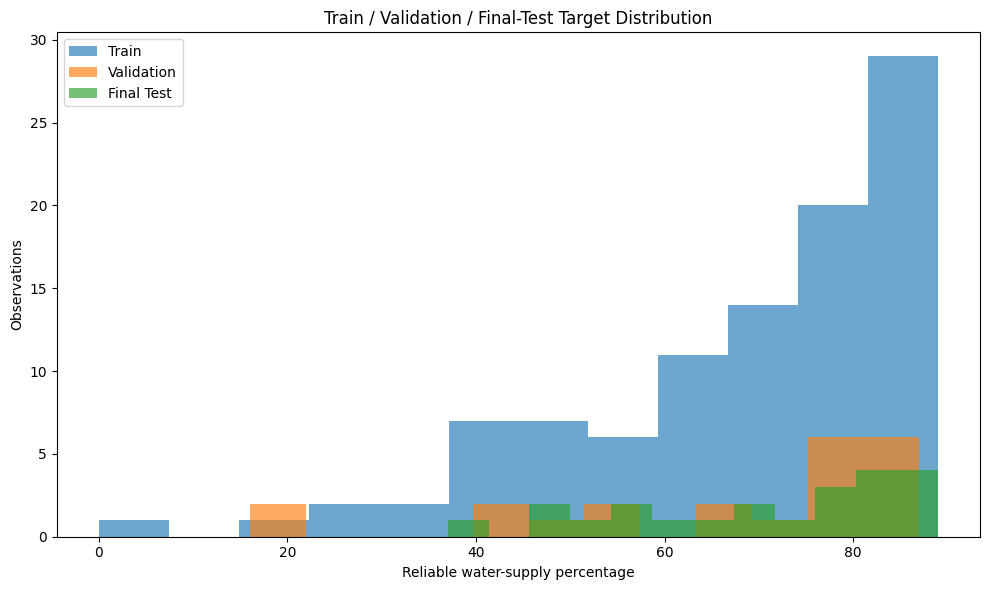

In [66]:
# ============================================================
# 12. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

def make_target_bins(y_values, max_bins=5):
    try:
        bins = pd.qcut(
            y_values,
            q=min(max_bins, y_values.nunique()),
            duplicates="drop"
        )
        if bins.nunique() >= 2:
            return bins
    except Exception:
        pass
    return None

target_bins = make_target_bins(y)

if target_bins is not None:
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X_base,
        y,
        test_size=0.15,
        random_state=RANDOM_STATE,
        stratify=target_bins
    )
else:
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X_base,
        y,
        test_size=0.15,
        random_state=RANDOM_STATE
    )

train_bins = make_target_bins(y_train_val)

if train_bins is not None:
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=0.1764705882,
        random_state=RANDOM_STATE,
        stratify=train_bins
    )
else:
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=0.1764705882,
        random_state=RANDOM_STATE
    )

split_summary = pd.DataFrame([
    {"split": "Train", "rows": len(X_train), "percent_of_total": 100 * len(X_train) / len(X_base)},
    {"split": "Validation", "rows": len(X_val), "percent_of_total": 100 * len(X_val) / len(X_base)},
    {"split": "Final Test", "rows": len(X_test), "percent_of_total": 100 * len(X_test) / len(X_base)},
])

display(split_summary)

split_summary.to_csv(
    os.path.join(MODEL_EVALUATION_DIR, "data_split_summary.csv"),
    index=False
)

plt.figure(figsize=(10, 6))
plt.hist(y_train, bins=12, alpha=0.65, label="Train")
plt.hist(y_val, bins=12, alpha=0.65, label="Validation")
plt.hist(y_test, bins=12, alpha=0.65, label="Final Test")
plt.xlabel("Reliable water-supply percentage")
plt.ylabel("Observations")
plt.title("Train / Validation / Final-Test Target Distribution")
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_VISUALISATION_DIR, "train_validation_test_split.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

## 13. Model design

This is a **regression** problem.

Models:
1. DummyRegressor — minimum baseline.
2. Ridge Regression — regularised linear baseline.
3. Random Forest — non-linear ensemble.
4. Gradient Boosting — sequential non-linear boosting.
5. HistGradientBoosting — efficient gradient boosting for tabular data.
6. Extra Trees — randomized tree ensemble.

The model is not selected on test performance. Validation RMSE is the primary selection metric, supported by MAE and R².

In [67]:
# ============================================================
# 13. PREPROCESSING PIPELINES
# ============================================================

def make_preprocessor(X):
    numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ], remainder="drop")

model_estimators = {
    "Dummy Baseline": DummyRegressor(strategy="mean"),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
    "HistGradientBoosting": HistGradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

pipelines = {
    name: Pipeline([
        ("preprocessor", make_preprocessor(X_train)),
        ("model", estimator)
    ])
    for name, estimator in model_estimators.items()
}

print("Regression pipelines prepared:", len(pipelines))

Regression pipelines prepared: 6


In [68]:
# ============================================================
# 14. MODEL COMPARISON — VALIDATION SET
# ============================================================

def regression_metrics(y_true, y_pred):
    y_true_array = np.asarray(y_true, dtype=float)
    y_pred_array = np.asarray(y_pred, dtype=float)

    rmse = np.sqrt(mean_squared_error(y_true_array, y_pred_array))
    mae = mean_absolute_error(y_true_array, y_pred_array)
    r2 = r2_score(y_true_array, y_pred_array)

    nonzero = np.abs(y_true_array) > 1e-9
    if nonzero.any():
        mape = np.mean(
            np.abs(
                (y_true_array[nonzero] - y_pred_array[nonzero])
                / y_true_array[nonzero]
            )
        ) * 100
    else:
        mape = np.nan

    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "R2": float(r2),
        "MAPE_pct": float(mape)
    }

validation_records = []
fitted_models = {}

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    prediction = pipeline.predict(X_val)
    metrics = regression_metrics(y_val, prediction)

    validation_records.append({
        "model": name,
        "split": "validation",
        **metrics
    })
    fitted_models[name] = pipeline

validation_results = pd.DataFrame(validation_records).sort_values(
    "RMSE", ascending=True
)

display(validation_results)

validation_results.to_csv(
    os.path.join(MODEL_EVALUATION_DIR, "model_comparison_validation.csv"),
    index=False
)

,model,split,MAE,RMSE,R2,MAPE_pct
1,Ridge Regression,validation,9.950301,13.323312,0.602134,25.808723
5,Extra Trees,validation,8.591023,13.420557,0.596305,24.492252
3,Gradient Boosting,validation,9.166318,13.692868,0.579756,26.402664
2,Random Forest,validation,9.085795,13.926290,0.565307,25.064449
4,HistGradientBoosting,validation,11.003800,14.401011,0.535166,29.485000
0,Dummy Baseline,validation,17.121818,21.161453,-0.003698,48.417392


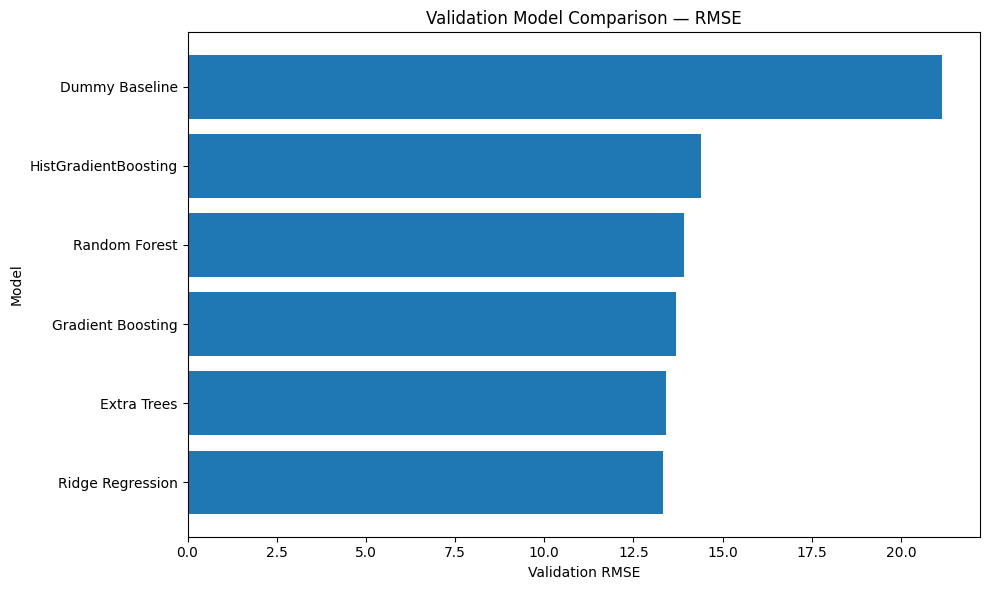

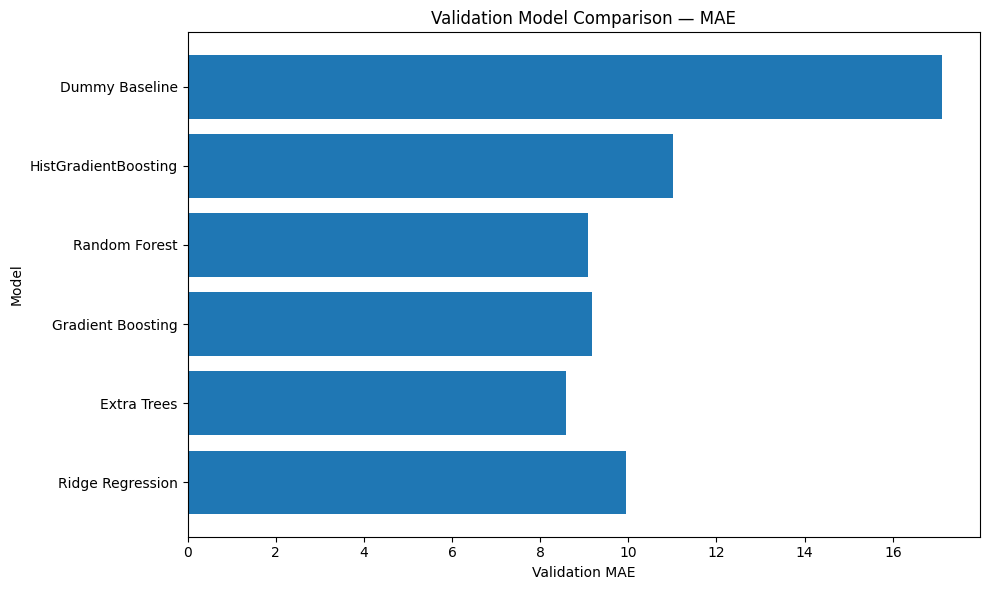

In [69]:
# ============================================================
# 15. MODEL PERFORMANCE VISUALS
# ============================================================

plot_data = validation_results.sort_values("RMSE", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_data["model"], plot_data["RMSE"])
plt.xlabel("Validation RMSE")
plt.ylabel("Model")
plt.title("Validation Model Comparison — RMSE")
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_VISUALISATION_DIR, "model_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

plt.figure(figsize=(10, 6))
plt.barh(plot_data["model"], plot_data["MAE"])
plt.xlabel("Validation MAE")
plt.ylabel("Model")
plt.title("Validation Model Comparison — MAE")
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_VISUALISATION_DIR, "model_comparison_mae.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

## 16. Cross-validation

Cross-validation is performed on the training partition only. The final test set is not involved.

Because the current target is cross-sectional rather than a dated event series, standard shuffled K-fold CV is appropriate here. A future event-level outage model should use time-aware validation such as `TimeSeriesSplit`.

,model,cv_folds,mean_MAE,std_MAE,mean_RMSE,std_RMSE,mean_R2,std_R2
1,Ridge Regression,5,9.351573,1.530640,12.704402,4.047465,0.505375,0.189465
2,Random Forest,5,9.093000,1.837988,12.927291,4.246033,0.494846,0.189502
5,Extra Trees,5,8.630000,2.138906,13.103079,4.816492,0.483286,0.230578
3,Gradient Boosting,5,9.556301,1.668868,13.372164,3.994175,0.459197,0.172584
4,HistGradientBoosting,5,10.441892,1.556523,14.185151,3.405195,0.388322,0.137784
0,Dummy Baseline,5,14.989500,1.503568,18.413713,2.603347,-0.036425,0.044225


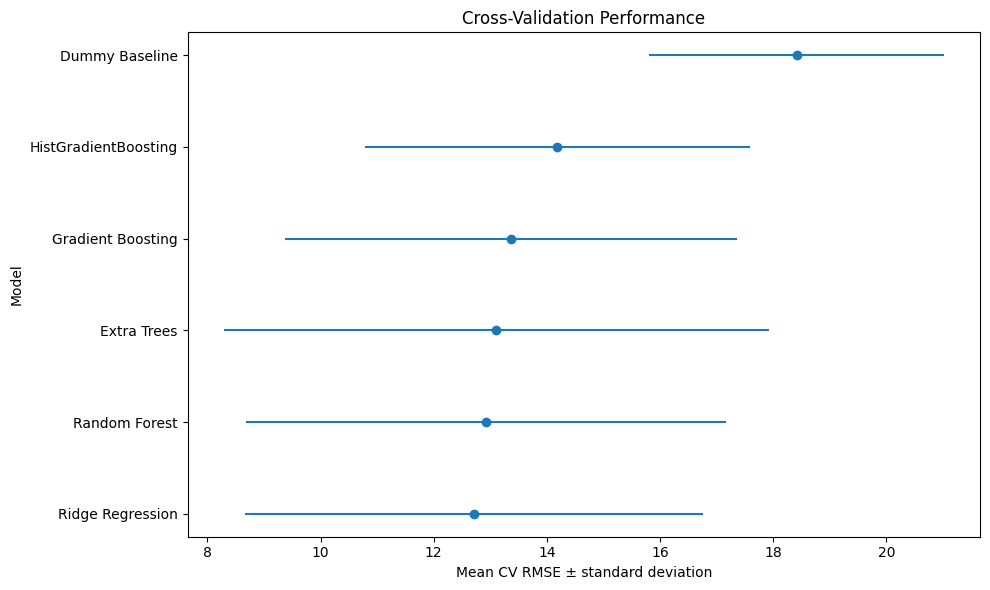

In [70]:
# ============================================================
# 16. CROSS-VALIDATION
# ============================================================

cv_folds = min(5, max(2, len(X_train) // 10))

cv = KFold(
    n_splits=cv_folds,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_records = []

for name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        return_train_score=False,
        n_jobs=-1
    )

    cv_records.append({
        "model": name,
        "cv_folds": cv_folds,
        "mean_MAE": -scores["test_MAE"].mean(),
        "std_MAE": scores["test_MAE"].std(),
        "mean_RMSE": -scores["test_RMSE"].mean(),
        "std_RMSE": scores["test_RMSE"].std(),
        "mean_R2": scores["test_R2"].mean(),
        "std_R2": scores["test_R2"].std()
    })

cv_results = pd.DataFrame(cv_records).sort_values(
    "mean_RMSE", ascending=True
)

display(cv_results)

cv_results.to_csv(
    os.path.join(MODEL_EVALUATION_DIR, "cross_validation_results.csv"),
    index=False
)

plt.figure(figsize=(10, 6))
plt.errorbar(
    cv_results["mean_RMSE"],
    cv_results["model"],
    xerr=cv_results["std_RMSE"],
    fmt="o"
)
plt.xlabel("Mean CV RMSE ± standard deviation")
plt.ylabel("Model")
plt.title("Cross-Validation Performance")
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_VISUALISATION_DIR, "cv_performance.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

## 17. Hyperparameter tuning

The tuning stage uses training data only. The validation set is used to compare tuned models; the final test set remains untouched.

Tuning: Ridge Regression
Tuning: Random Forest
Tuning: Gradient Boosting
Tuning: HistGradientBoosting
Tuning: Extra Trees


,model,best_cv_RMSE,validation_RMSE,validation_MAE,validation_R2,best_params
4,Extra Trees,12.182241,12.912603,8.865388,0.626286,"{""model__max_depth"": 4, ""model__max_features"":..."
2,Gradient Boosting,12.383536,12.944760,8.717097,0.624422,"{""model__learning_rate"": 0.1, ""model__max_dept..."
0,Ridge Regression,12.500045,13.112211,9.704538,0.614642,"{""model__alpha"": 10.0}"
1,Random Forest,12.561589,13.852593,10.082089,0.569895,"{""model__max_depth"": 4, ""model__max_features"":..."
3,HistGradientBoosting,13.525602,13.918564,10.523219,0.565789,"{""model__l2_regularization"": 1.0, ""model__lear..."


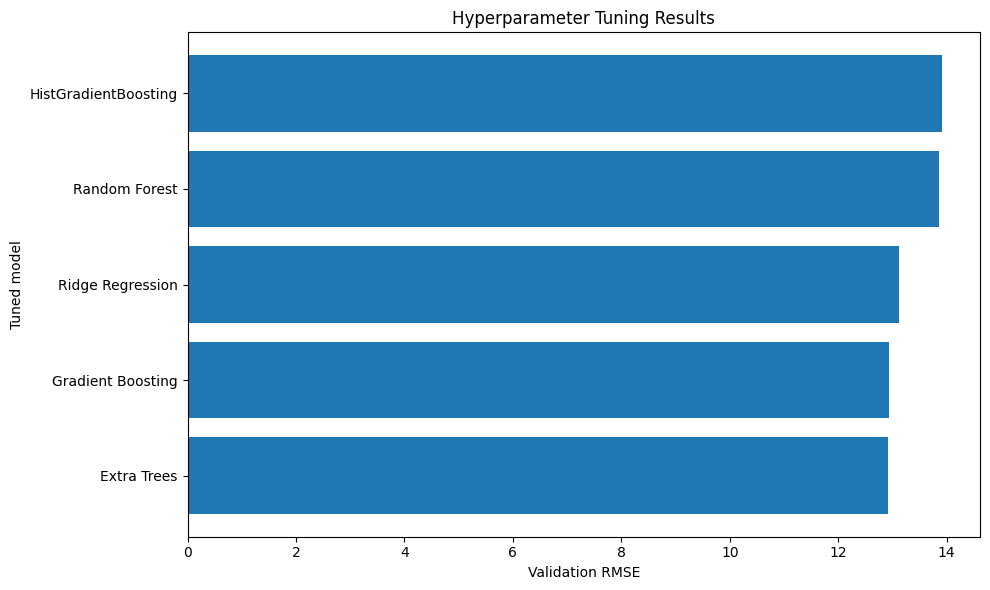

In [71]:
# ============================================================
# 17. HYPERPARAMETER TUNING
# ============================================================

tuning_spaces = {
    "Ridge Regression": (
        pipelines["Ridge Regression"],
        {
            "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
        }
    ),
    "Random Forest": (
        pipelines["Random Forest"],
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 4, 8],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", 0.7]
        }
    ),
    "Gradient Boosting": (
        pipelines["Gradient Boosting"],
        {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [1, 2, 3],
            "model__min_samples_leaf": [1, 2]
        }
    ),
    "HistGradientBoosting": (
        pipelines["HistGradientBoosting"],
        {
            "model__max_iter": [100, 200],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_leaf_nodes": [7, 15, 31],
            "model__l2_regularization": [0.0, 0.5, 1.0]
        }
    ),
    "Extra Trees": (
        pipelines["Extra Trees"],
        {
            "model__n_estimators": [200, 400],
            "model__max_depth": [None, 4, 8],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", 0.7]
        }
    )
}

tuning_records = []
tuned_models = {}
tuning_cv_records = []

for name, (pipeline, param_grid) in tuning_spaces.items():
    print("Tuning:", name)

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=False
    )

    grid.fit(X_train, y_train)

    tuned = grid.best_estimator_
    validation_prediction = tuned.predict(X_val)
    validation_metric = regression_metrics(y_val, validation_prediction)

    tuning_records.append({
        "model": name,
        "best_cv_RMSE": -grid.best_score_,
        "validation_RMSE": validation_metric["RMSE"],
        "validation_MAE": validation_metric["MAE"],
        "validation_R2": validation_metric["R2"],
        "best_params": json.dumps(grid.best_params_, default=str)
    })

    # Save the complete CV search table for evidence.
    search_table = pd.DataFrame(grid.cv_results_)
    search_table.insert(0, "model_name", name)
    tuning_cv_records.append(search_table)

    tuned_models[name] = tuned

hyperparameter_results = pd.DataFrame(tuning_records).sort_values(
    "validation_RMSE", ascending=True
)

display(hyperparameter_results)

hyperparameter_results.to_csv(
    os.path.join(MODEL_EVALUATION_DIR, "hyperparameter_results.csv"),
    index=False
)

if tuning_cv_records:
    full_tuning_results = pd.concat(
        tuning_cv_records,
        ignore_index=True
    )
    full_tuning_results.to_csv(
        os.path.join(MODEL_EVALUATION_DIR, "hyperparameter_search_all_results.csv"),
        index=False
    )

plt.figure(figsize=(10, 6))
plt.barh(
    hyperparameter_results["model"],
    hyperparameter_results["validation_RMSE"]
)
plt.xlabel("Validation RMSE")
plt.ylabel("Tuned model")
plt.title("Hyperparameter Tuning Results")
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_VISUALISATION_DIR, "hyperparameter_results.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

## 18. Select the final model

Selection is based on **validation RMSE**, with cross-validation performance used as supporting evidence.

The final test set is not used to select the model.

In [72]:
# ============================================================
# 18. MODEL SELECTION
# ============================================================

if hyperparameter_results.empty:
    raise RuntimeError("Hyperparameter tuning produced no results.")

BEST_MODEL_NAME = hyperparameter_results.iloc[0]["model"]
BEST_VALIDATION_RMSE = float(
    hyperparameter_results.iloc[0]["validation_RMSE"]
)

selected_tuned_model = tuned_models[BEST_MODEL_NAME]

print("Selected final model:", BEST_MODEL_NAME)
print("Validation RMSE:", BEST_VALIDATION_RMSE)
print("Selection criterion: lowest validation RMSE.")
print("Final test set has not been used for model selection.")

Selected final model: Extra Trees
Validation RMSE: 12.91260285388867
Selection criterion: lowest validation RMSE.
Final test set has not been used for model selection.


## 19. Geographic experiment

Two experiments are compared using the same target and same split:

- **Model A:** non-geographic predictors.
- **Model B:** same predictors plus `wsa_name`.

The municipality label is treated as a categorical geographic/service-area fixed effect. It is not presented as a physical geographic variable such as latitude or longitude.

Because the reliability dataset is cross-sectional and contains municipality-level observations, this experiment asks whether municipality identity adds predictive information.

In [73]:
# ============================================================
# 19. GEOGRAPHIC EXPERIMENT
# ============================================================

if GEO_KEY not in X_base.columns:
    geographic_experiment = pd.DataFrame([{
        "model_group": "Geographic experiment",
        "status": "NOT AVAILABLE",
        "reason": f"{GEO_KEY} is not available."
    }])
else:
    X_no_geo = X_base.drop(columns=[GEO_KEY])
    X_with_geo = X_base.copy()

    geo_models = {
        "Model A - Water/Population features": X_no_geo,
        "Model B - + Municipality geography": X_with_geo
    }

    geo_records = []

    for group_name, X_group in geo_models.items():
        train_group = X_group.loc[X_train.index]
        val_group = X_group.loc[X_val.index]

        candidate = Pipeline([
            ("preprocessor", make_preprocessor(train_group)),
            ("model", ExtraTreesRegressor(
                n_estimators=400,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])

        candidate.fit(train_group, y_train.loc[train_group.index])
        prediction = candidate.predict(val_group)

        metrics = regression_metrics(
            y_val.loc[val_group.index],
            prediction
        )

        geo_records.append({
            "model_group": group_name,
            **metrics
        })

    geographic_experiment = pd.DataFrame(
        geo_records
    ).sort_values("RMSE", ascending=True)

display(geographic_experiment)

geographic_experiment.to_csv(
    os.path.join(MODEL_EVALUATION_DIR, "geographic_experiment.csv"),
    index=False
)

,model_group,MAE,RMSE,R2,MAPE_pct
1,Model B - + Municipality geography,8.591023,13.420557,0.596305,24.492252
0,Model A - Water/Population features,10.532727,14.803579,0.508814,25.990813


In [74]:
# ============================================================
# 20. FINAL FIT ON TRAIN + VALIDATION, THEN ONE TEST EVALUATION
# ============================================================

X_train_validation = pd.concat([X_train, X_val], axis=0)
y_train_validation = pd.concat([y_train, y_val], axis=0)

final_model = clone(selected_tuned_model)
final_model.fit(X_train_validation, y_train_validation)

# The test set is evaluated here for the first time.
test_prediction = final_model.predict(X_test)

final_test_metrics = regression_metrics(
    y_test,
    test_prediction
)

final_test_results = pd.DataFrame([{
    "model": BEST_MODEL_NAME,
    "split": "final_test",
    **final_test_metrics
}])

display(final_test_results)

final_test_results.to_csv(
    os.path.join(MODEL_EVALUATION_DIR, "final_test_metrics.csv"),
    index=False
)

joblib.dump(
    final_model,
    os.path.join(MODELS_DIR, "best_model.joblib")
)

print("Final model saved to Outputs/Models/best_model.joblib")

,model,split,MAE,RMSE,R2,MAPE_pct
0,Extra Trees,final_test,7.856324,10.317815,0.553584,11.756575


Final model saved to Outputs/Models/best_model.joblib


In [75]:
# ============================================================
# 21. FINAL TEST PREDICTIONS
# ============================================================

test_predictions_df = X_test.copy()

test_predictions_df["actual_reliable_supply_pct"] = y_test.values
test_predictions_df["predicted_reliable_supply_pct"] = test_prediction
test_predictions_df["predicted_outage_risk_proxy_pct"] = 100 - test_prediction
test_predictions_df["absolute_error"] = np.abs(
    test_predictions_df["actual_reliable_supply_pct"]
    - test_predictions_df["predicted_reliable_supply_pct"]
)

test_predictions_df.to_csv(
    os.path.join(PREDICTIONS_DIR, "test_predictions.csv"),
    index=False
)

display(
    test_predictions_df[
        [
            c for c in [
                GEO_KEY,
                "actual_reliable_supply_pct",
                "predicted_reliable_supply_pct",
                "predicted_outage_risk_proxy_pct",
                "absolute_error"
            ]
            if c in test_predictions_df.columns
        ]
    ]
)

,wsa_name,actual_reliable_supply_pct,predicted_reliable_supply_pct,predicted_outage_risk_proxy_pct,absolute_error
27,Ngwathe,70.0,77.192660,22.807340,7.192660
92,Rustenburg,69.0,76.972189,23.027811,7.972189
93,!Kheis,62.0,73.851218,26.148782,11.851218
115,Thembelihle,84.0,75.216255,24.783745,8.783745
95,Dikgatlong,81.0,75.246608,24.753392,5.753392
117,Ubuntu,84.0,74.396804,25.603196,9.603196
24,Mohokare,46.0,77.163207,22.836793,31.163207
9,Makana,77.0,74.848093,25.151907,2.151907
63,Sekhukhune,37.0,35.824094,64.175906,1.175906
137,Prince Albert,89.0,77.318847,22.681153,11.681153


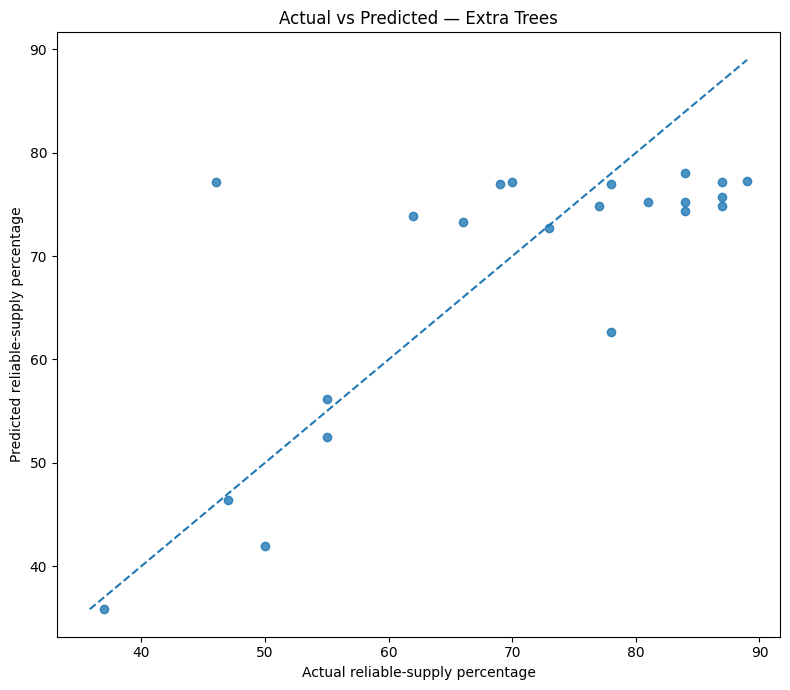

In [76]:
# ============================================================
# 22. ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 7))
plt.scatter(
    y_test,
    test_prediction,
    alpha=0.8
)

line_min = min(float(y_test.min()), float(np.min(test_prediction)))
line_max = max(float(y_test.max()), float(np.max(test_prediction)))

plt.plot(
    [line_min, line_max],
    [line_min, line_max],
    linestyle="--"
)

plt.xlabel("Actual reliable-supply percentage")
plt.ylabel("Predicted reliable-supply percentage")
plt.title(f"Actual vs Predicted — {BEST_MODEL_NAME}")
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_VISUALISATION_DIR, "actual_vs_predicted.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

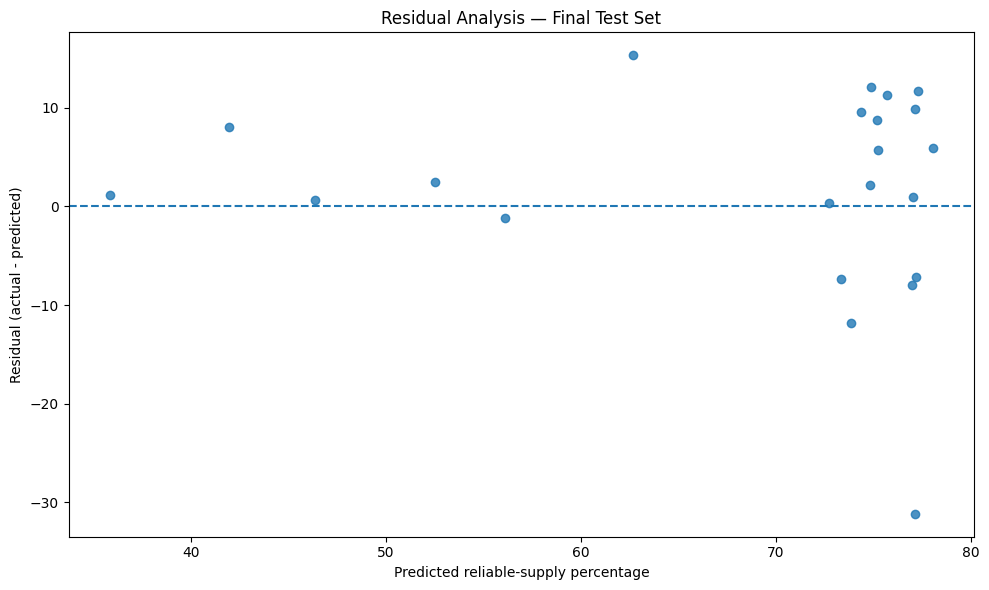

In [77]:
# ============================================================
# 23. RESIDUAL ANALYSIS
# ============================================================

residuals = y_test.values - test_prediction

plt.figure(figsize=(10, 6))
plt.scatter(
    test_prediction,
    residuals,
    alpha=0.8
)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted reliable-supply percentage")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residual Analysis — Final Test Set")
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_VISUALISATION_DIR, "residual_analysis.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

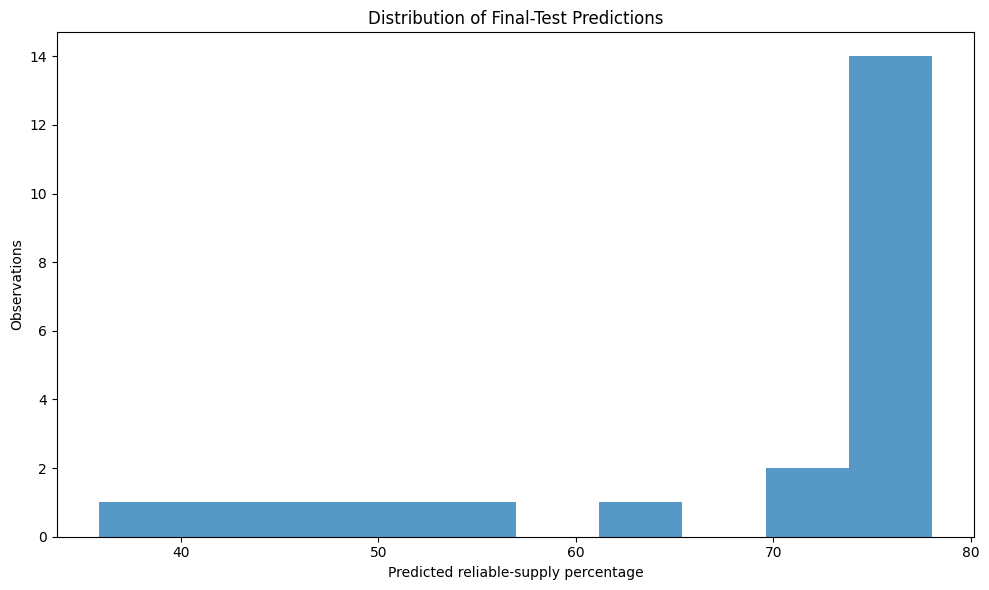

In [78]:
# ============================================================
# 24. PREDICTION DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))
plt.hist(
    test_prediction,
    bins=10,
    alpha=0.75
)
plt.xlabel("Predicted reliable-supply percentage")
plt.ylabel("Observations")
plt.title("Distribution of Final-Test Predictions")
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_VISUALISATION_DIR, "prediction_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

,wsa_name,predicted_reliable_supply_pct,predicted_outage_risk_proxy_pct
6,Midvaal,72.517738,27.482262
8,Rand West City,74.579190,25.420810
7,Mogale City,75.447005,24.552995
5,Merafong City,77.333304,22.666696
3,Emfuleni,77.554274,22.445726
4,Lesedi,77.712497,22.287503
1,City of Tshwane Metropolitan Municipality,78.159630,21.840370
0,City of Johannesburg Metropolitan Municipality,78.239774,21.760226
2,Ekurhuleni Metropolitan Municipality,78.552546,21.447454


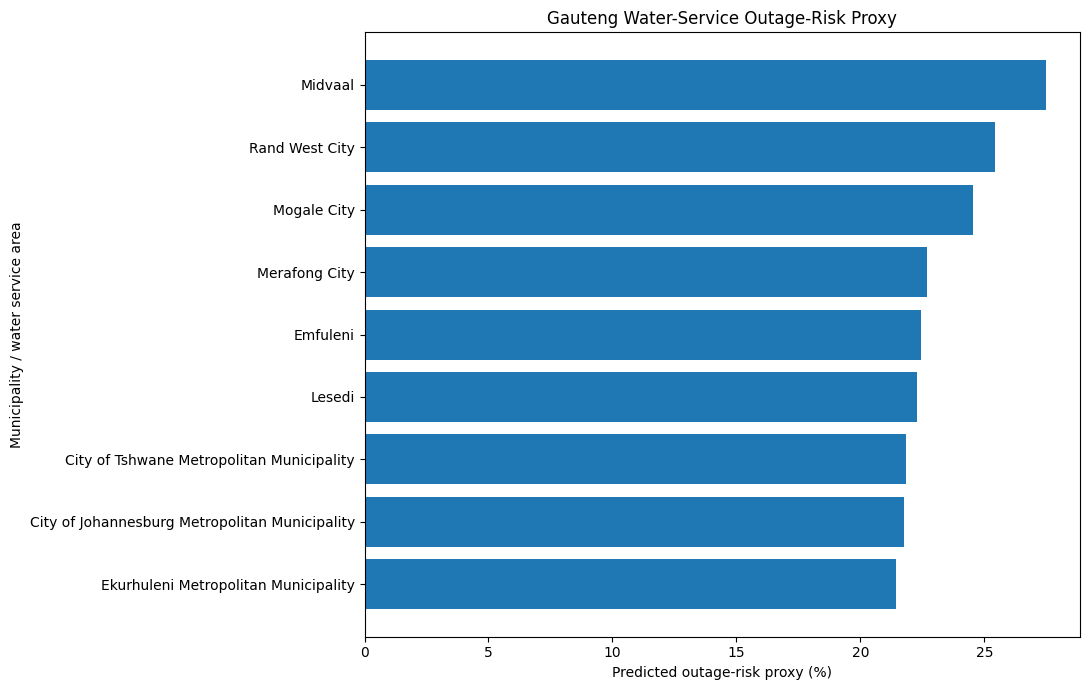

In [79]:
# ============================================================
# 25. GAUTENG MUNICIPALITY RISK-PROXY PREDICTIONS
# ============================================================

GAUTENG_MUNICIPALITIES = {
    "City of Johannesburg Metropolitan Municipality",
    "City of Tshwane Metropolitan Municipality",
    "Ekurhuleni Metropolitan Municipality",
    "Emfuleni",
    "Lesedi",
    "Merafong City",
    "Midvaal",
    "Mogale City",
    "Rand West City",
}

gauteng_mask = X_base[GEO_KEY].isin(GAUTENG_MUNICIPALITIES)
X_gauteng = X_base.loc[gauteng_mask].copy()

if len(X_gauteng) > 0:
    gauteng_prediction = final_model.predict(X_gauteng)

    gauteng_predictions_df = pd.DataFrame({
        GEO_KEY: X_gauteng[GEO_KEY].values,
        "predicted_reliable_supply_pct": gauteng_prediction,
        "predicted_outage_risk_proxy_pct": 100 - gauteng_prediction
    }).sort_values(
        "predicted_outage_risk_proxy_pct",
        ascending=False
    )

    gauteng_predictions_df.to_csv(
        os.path.join(PREDICTIONS_DIR, "gauteng_municipality_predictions.csv"),
        index=False
    )

    display(gauteng_predictions_df)

    plot_regional = gauteng_predictions_df.sort_values(
        "predicted_outage_risk_proxy_pct"
    )

    plt.figure(figsize=(11, 7))
    plt.barh(
        plot_regional[GEO_KEY],
        plot_regional["predicted_outage_risk_proxy_pct"]
    )
    plt.xlabel("Predicted outage-risk proxy (%)")
    plt.ylabel("Municipality / water service area")
    plt.title("Gauteng Water-Service Outage-Risk Proxy")
    plt.tight_layout()
    plt.savefig(
        os.path.join(MODEL_VISUALISATION_DIR, "regional_risk.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()
else:
    gauteng_predictions_df = pd.DataFrame()
    print("No named Gauteng municipalities were found in the target dataset.")

## 20. Time-series prediction visualisation

A true prediction-over-time graph is intentionally **not generated** for the primary model.

The selected target is a cross-sectional reliability snapshot, not a dated sequence of outage events. Creating artificial dates or ordering municipalities as if they were temporal observations would be misleading.

A future direct-outage model should use event timestamps and time-aware validation.

In [80]:
# ============================================================
# 26. TEMPORAL SUPPORT AUDIT
# ============================================================

target_date_columns = [
    c for c in reliability_df.columns
    if any(
        token in str(c).lower()
        for token in ["date", "datetime", "timestamp", "time_frame"]
    )
]

temporal_support = pd.DataFrame([{
    "target_dataset": os.path.relpath(RELIABILITY_PATH, PROJECT_ROOT),
    "detected_temporal_columns": ", ".join(map(str, target_date_columns)),
    "supports_true_time_series_outage_prediction": bool(
        target_date_columns
    ),
    "decision": (
        "Temporal modelling possible after event-level target validation."
        if target_date_columns
        else "Do not fabricate a time-series prediction."
    )
}])

display(temporal_support)

temporal_support.to_csv(
    os.path.join(MODEL_EVALUATION_DIR, "temporal_support_audit.csv"),
    index=False
)

,target_dataset,detected_temporal_columns,supports_true_time_series_outage_prediction,decision
0,Outputs/FeatureEngineering/NIWIS_Water_Supply_...,,False,Do not fabricate a time-series prediction.


,feature,importance
8,numeric__water_access_gap_pct,0.314856
7,numeric__water_access_rate_pct,0.278386
10,numeric__rural_population_share_pct,0.166285
9,numeric__urban_population_share_pct,0.115326
4,numeric__rural_population,0.051211
5,numeric__rural_population_with_access_to_water,0.024542
0,numeric__population,0.007950
6,numeric__log_population,0.007181
13,numeric__missingindicator_urban_population_wit...,0.006539
1,numeric__population_with_access_to_water,0.006153


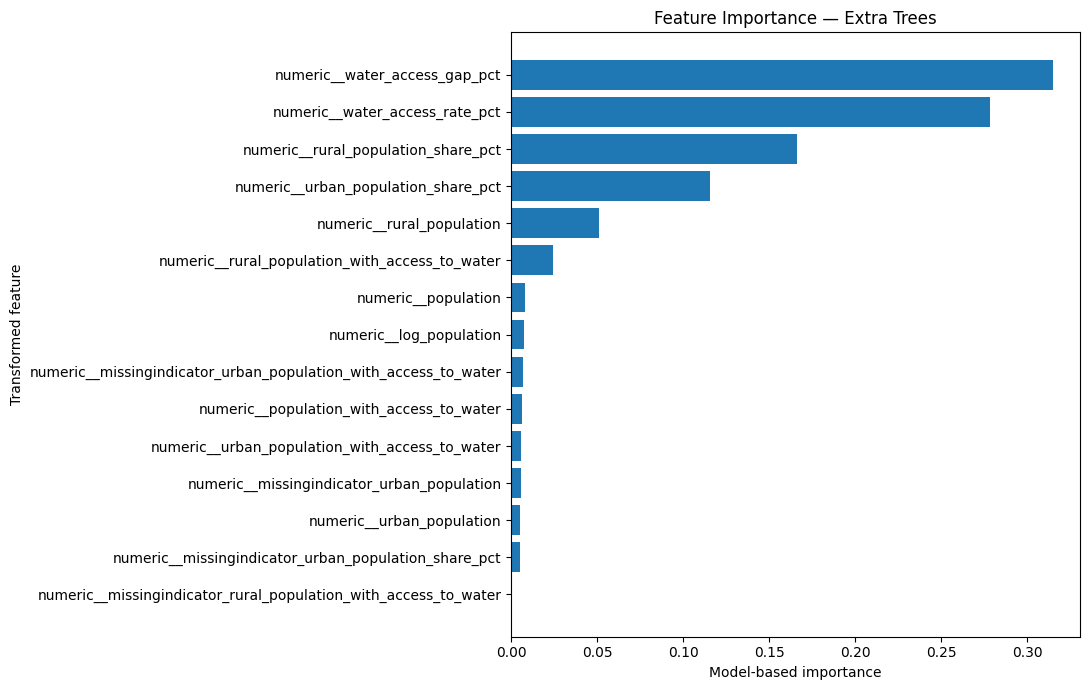

In [81]:
# ============================================================
# 27. MODEL-BASED FEATURE IMPORTANCE
# ============================================================

preprocessor_final = final_model.named_steps["preprocessor"]
model_final = final_model.named_steps["model"]

try:
    transformed_feature_names = list(
        preprocessor_final.get_feature_names_out()
    )
except Exception:
    transformed_feature_names = []

if hasattr(model_final, "feature_importances_") and transformed_feature_names:
    feature_importance_df = pd.DataFrame({
        "feature": transformed_feature_names,
        "importance": model_final.feature_importances_
    }).sort_values("importance", ascending=False)

elif hasattr(model_final, "coef_") and transformed_feature_names:
    coefficients = np.asarray(model_final.coef_).ravel()
    feature_importance_df = pd.DataFrame({
        "feature": transformed_feature_names,
        "importance": np.abs(coefficients)
    }).sort_values("importance", ascending=False)

else:
    feature_importance_df = pd.DataFrame(
        columns=["feature", "importance"]
    )

feature_importance_df.to_csv(
    os.path.join(MODEL_EVALUATION_DIR, "feature_importance.csv"),
    index=False
)

display(feature_importance_df.head(20))

if not feature_importance_df.empty:
    top = feature_importance_df.head(15).sort_values("importance")

    plt.figure(figsize=(11, 7))
    plt.barh(top["feature"], top["importance"])
    plt.xlabel("Model-based importance")
    plt.ylabel("Transformed feature")
    plt.title(f"Feature Importance — {BEST_MODEL_NAME}")
    plt.tight_layout()
    plt.savefig(
        os.path.join(MODEL_VISUALISATION_DIR, "feature_importance.png"),
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()

,feature,importance_mean,importance_std
8,water_access_rate_pct,2.674281e+00,1.072935e+00
9,water_access_gap_pct,2.459256e+00,9.777579e-01
11,rural_population_share_pct,5.450940e-01,5.909520e-01
10,urban_population_share_pct,1.931551e-01,2.669898e-01
5,rural_population,1.296149e-01,1.324314e-01
6,rural_population_with_access_to_water,3.423769e-02,5.143867e-02
1,population,1.271347e-02,6.990098e-02
0,wsa_name,-2.753353e-15,8.837264e-16
2,population_with_access_to_water,-1.861139e-02,3.209215e-02
3,urban_population,-7.768006e-02,2.341815e-02


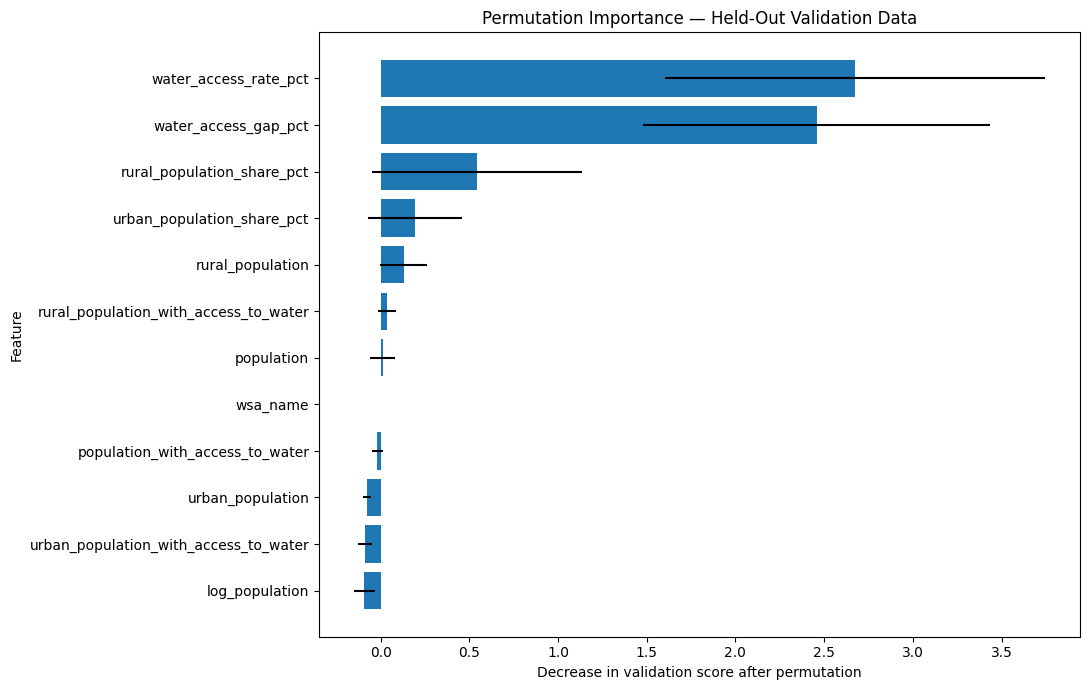

In [82]:
# ============================================================
# 28. PERMUTATION IMPORTANCE ON HELD-OUT VALIDATION DATA
# ============================================================

permutation = permutation_importance(
    selected_tuned_model,
    X_val,
    y_val,
    scoring="neg_root_mean_squared_error",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": permutation.importances_mean,
    "importance_std": permutation.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

permutation_importance_df.to_csv(
    os.path.join(MODEL_EVALUATION_DIR, "permutation_importance.csv"),
    index=False
)

display(permutation_importance_df.head(20))

top_perm = permutation_importance_df.head(15).sort_values(
    "importance_mean"
)

plt.figure(figsize=(11, 7))
plt.barh(
    top_perm["feature"],
    top_perm["importance_mean"],
    xerr=top_perm["importance_std"]
)
plt.xlabel("Decrease in validation score after permutation")
plt.ylabel("Feature")
plt.title("Permutation Importance — Held-Out Validation Data")
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_VISUALISATION_DIR, "permutation_importance.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

In [83]:
# ============================================================
# 29. MULTICOLLINEARITY / CORRELATION DIAGNOSTIC
# ============================================================

numeric_features = X_base.select_dtypes(include=[np.number]).copy()

correlation_records = []

if not numeric_features.empty:
    corr_matrix = numeric_features.corr(numeric_only=True)

    for i, col_a in enumerate(corr_matrix.columns):
        for col_b in corr_matrix.columns[i + 1:]:
            correlation_records.append({
                "feature_1": col_a,
                "feature_2": col_b,
                "correlation": corr_matrix.loc[col_a, col_b],
                "absolute_correlation": abs(corr_matrix.loc[col_a, col_b])
            })

correlation_pairs_df = pd.DataFrame(
    correlation_records
).sort_values(
    "absolute_correlation",
    ascending=False
)

correlation_pairs_df.to_csv(
    os.path.join(MODEL_EVALUATION_DIR, "feature_correlation_pairs.csv"),
    index=False
)

display(correlation_pairs_df.head(20))

print(
    "High-correlation pairs (absolute correlation >= 0.80):",
    int(
        (correlation_pairs_df["absolute_correlation"] >= 0.80).sum()
    )
    if not correlation_pairs_df.empty else 0
)

,feature_1,feature_2,correlation,absolute_correlation
49,water_access_rate_pct,water_access_gap_pct,-1.000000,1.000000
54,urban_population_share_pct,rural_population_share_pct,-1.000000,1.000000
19,urban_population,urban_population_with_access_to_water,0.999672,0.999672
0,population,population_with_access_to_water,0.989203,0.989203
10,population_with_access_to_water,urban_population,0.982593,0.982593
11,population_with_access_to_water,urban_population_with_access_to_water,0.980484,0.980484
1,population,urban_population,0.953734,0.953734
2,population,urban_population_with_access_to_water,0.949004,0.949004
34,rural_population,rural_population_with_access_to_water,0.946337,0.946337
37,rural_population,water_access_gap_pct,0.788360,0.788360


High-correlation pairs (absolute correlation >= 0.80): 9


,training_rows,training_fraction,train_RMSE,validation_RMSE
0,61,0.50,11.036518,11.895521
1,85,0.70,10.516299,12.766555
2,103,0.85,10.882446,10.333974
3,122,1.00,11.016031,10.441841


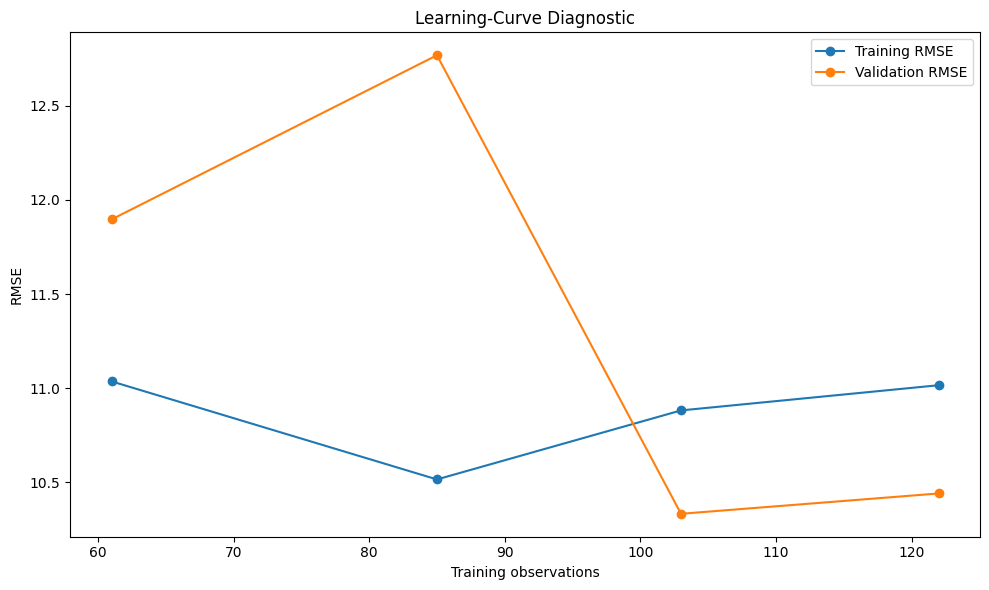

In [84]:
# ============================================================
# 30. LEARNING-CURVE DIAGNOSTIC
# ============================================================

fractions = [0.50, 0.70, 0.85, 1.00]
learning_records = []

rng = np.random.default_rng(RANDOM_STATE)

for fraction in fractions:
    n = max(5, int(len(X_train_validation) * fraction))

    if n >= len(X_train_validation):
        X_subset = X_train_validation
        y_subset = y_train_validation
    else:
        selected_indices = rng.choice(
            len(X_train_validation),
            size=n,
            replace=False
        )
        X_subset = X_train_validation.iloc[selected_indices]
        y_subset = y_train_validation.iloc[selected_indices]

    diagnostic_model = clone(selected_tuned_model)
    diagnostic_model.fit(X_subset, y_subset)

    train_prediction = diagnostic_model.predict(X_subset)
    validation_prediction = diagnostic_model.predict(X_val)

    learning_records.append({
        "training_rows": len(X_subset),
        "training_fraction": fraction,
        "train_RMSE": np.sqrt(
            mean_squared_error(y_subset, train_prediction)
        ),
        "validation_RMSE": np.sqrt(
            mean_squared_error(y_val, validation_prediction)
        )
    })

learning_curve_df = pd.DataFrame(learning_records)

display(learning_curve_df)

learning_curve_df.to_csv(
    os.path.join(MODEL_EVALUATION_DIR, "learning_curve_results.csv"),
    index=False
)

plt.figure(figsize=(10, 6))
plt.plot(
    learning_curve_df["training_rows"],
    learning_curve_df["train_RMSE"],
    marker="o",
    label="Training RMSE"
)
plt.plot(
    learning_curve_df["training_rows"],
    learning_curve_df["validation_RMSE"],
    marker="o",
    label="Validation RMSE"
)
plt.xlabel("Training observations")
plt.ylabel("RMSE")
plt.title("Learning-Curve Diagnostic")
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(MODEL_VISUALISATION_DIR, "learning_curve.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

## 21. Final configuration and report artefacts

In [85]:
# ============================================================
# 31. FINAL MODEL CONFIGURATION
# ============================================================

top_permutation_features = (
    permutation_importance_df.head(10)["feature"].tolist()
    if not permutation_importance_df.empty
    else []
)

geo_improved = None
if (
    len(geographic_experiment) >= 2
    and "RMSE" in geographic_experiment.columns
):
    model_a = geographic_experiment[
        geographic_experiment["model_group"].str.startswith("Model A")
    ]
    model_b = geographic_experiment[
        geographic_experiment["model_group"].str.startswith("Model B")
    ]

    if not model_a.empty and not model_b.empty:
        geo_improved = (
            float(model_b.iloc[0]["RMSE"])
            < float(model_a.iloc[0]["RMSE"])
        )

final_configuration = {
    "project": "ANLOK Water Prediction Project",
    "notebook": "Notebook 4",
    "random_state": RANDOM_STATE,
    "dataset_used": os.path.relpath(RELIABILITY_PATH, PROJECT_ROOT),
    "raw_target_column": RAW_TARGET_COLUMN,
    "model_target": "target_reliable_supply_pct",
    "problem_type": "regression",
    "true_outage_target_available": bool(true_outage_target_available),
    "outage_risk_proxy": "100 - predicted_reliable_supply_pct",
    "best_model": BEST_MODEL_NAME,
    "validation_selection_metric": "RMSE",
    "best_validation_RMSE": BEST_VALIDATION_RMSE,
    "final_test_metrics": final_test_metrics,
    "total_observations": int(len(X_base)),
    "training_rows": int(len(X_train)),
    "validation_rows": int(len(X_val)),
    "test_rows": int(len(X_test)),
    "features_before_engineering": int(len(reliability_df.columns) - 1),
    "features_after_engineering_before_preprocessing": int(X_base.shape[1]),
    "most_important_features": top_permutation_features,
    "geographic_features_improved_validation_RMSE": geo_improved,
    "weather_used_in_primary_model": False,
    "weather_reason": (
        "No validated municipality-date key links daily weather to the "
        "cross-sectional reliability target."
    ),
    "leakage_columns_removed": target_leakage_columns,
    "constant_columns_removed": constant_columns,
    "identifier_columns_removed": identifier_columns
}

with open(
    os.path.join(MODEL_EVALUATION_DIR, "final_model_configuration.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(final_configuration, f, indent=2, default=str)

print(json.dumps(final_configuration, indent=2, default=str))

{
  "project": "ANLOK Water Prediction Project",
  "notebook": "Notebook 4",
  "random_state": 42,
  "dataset_used": "Outputs/FeatureEngineering/NIWIS_Water_Supply_Reliability_-_population_16-Jul-2026__engineered.csv",
  "raw_target_column": "population_reliable_supply_1",
  "model_target": "target_reliable_supply_pct",
  "problem_type": "regression",
  "true_outage_target_available": false,
  "outage_risk_proxy": "100 - predicted_reliable_supply_pct",
  "best_model": "Extra Trees",
  "validation_selection_metric": "RMSE",
  "best_validation_RMSE": 12.91260285388867,
  "final_test_metrics": {
    "MAE": 7.856323799544911,
    "RMSE": 10.317814711325662,
    "R2": 0.553584011419614,
    "MAPE_pct": 11.756574668798372
  },
  "total_observations": 144,
  "training_rows": 100,
  "validation_rows": 22,
  "test_rows": 22,
  "features_before_engineering": 12,
  "features_after_engineering_before_preprocessing": 12,
  "most_important_features": [
    "water_access_rate_pct",
    "water_access_

In [86]:
# ============================================================
# 32. HUMAN-READABLE MODELLING REPORT
# ============================================================

gauteng_risk_statement = (
    "Gauteng municipality predictions were generated and saved."
    if not gauteng_predictions_df.empty
    else "No Gauteng municipality prediction table was generated."
)

report = f"""# ANLOK Water Prediction Project — Notebook 4 Modelling Report

## 1. Dataset
{os.path.relpath(RELIABILITY_PATH, PROJECT_ROOT)}

## 2. Target variable
`target_reliable_supply_pct`, derived from `{RAW_TARGET_COLUMN}`.

This is a water-service reliability target. It is used as an outage-risk proxy:
**outage-risk proxy = 100 - predicted reliable-supply percentage**.

The current project does not contain a verified event-level historical outage target, so this notebook does not claim direct outage-event prediction.

## 3. Observations
{len(X_base)}

## 4. Features before feature engineering
{final_configuration["features_before_engineering"]}

## 5. Features after feature engineering
{X_base.shape[1]}

## 6. Train / validation / test
- Train: {len(X_train)}
- Validation: {len(X_val)}
- Final test: {len(X_test)}

## 7. Models tested
{chr(10).join("- " + name for name in pipelines.keys())}

## 8. Best model
{BEST_MODEL_NAME}

## 9. Best validation performance
- Validation RMSE: {BEST_VALIDATION_RMSE:.4f}

## 10. Final test performance
- MAE: {final_test_metrics["MAE"]:.4f}
- RMSE: {final_test_metrics["RMSE"]:.4f}
- R²: {final_test_metrics["R2"]:.4f}
- MAPE: {final_test_metrics["MAPE_pct"]:.2f}%

## 11. Most important features
{chr(10).join("- " + feature for feature in top_permutation_features)}

## 12. Geographic experiment
Geographic features improved validation RMSE: {geo_improved}

## 13. Weather decision
Weather was not included in the primary model because the project does not provide a validated municipality-date key connecting daily weather observations to the cross-sectional reliability target.

## 14. Limitations
- No verified historical outage-event target.
- Reliability is a proxy rather than direct outage prediction.
- The selected target is cross-sectional rather than an event-level time series.
- Daily weather cannot be safely assigned to target observations without a municipality-date join.
- Small municipal samples limit claims about operational deployment.
- Predictions should be treated as decision-support estimates, not outage alarms.

## 15. Data needed for a true outage prediction system
- Historical outage/service-interruption events.
- Municipality or water-service-area identifier for every event.
- Outage start and end timestamps or duration.
- Outage cause/type.
- Pump, reservoir, treatment and infrastructure failure records.
- Maintenance records.
- Reservoir level/capacity observations where available.
- A consistent municipality-date key for joining weather.
- Water demand/consumption observations aligned to the same dates.

## 16. Notebook 5 recommendations
- Present the model comparison and cross-validation evidence.
- Present the untouched final-test metrics.
- Present Gauteng municipality risk-proxy predictions.
- Explain why reliability is a proxy rather than direct outage prediction.
- Present feature importance and the geographic experiment.
- Link model findings directly to Gauteng water-service challenges.
- Clearly document the data required for future direct outage prediction.

{gauteng_risk_statement}
"""

with open(
    os.path.join(MODEL_REPORTS_DIR, "notebook4_modelling_summary.md"),
    "w",
    encoding="utf-8"
) as f:
    f.write(report)

print(report)

# ANLOK Water Prediction Project — Notebook 4 Modelling Report

## 1. Dataset
Outputs/FeatureEngineering/NIWIS_Water_Supply_Reliability_-_population_16-Jul-2026__engineered.csv

## 2. Target variable
`target_reliable_supply_pct`, derived from `population_reliable_supply_1`.

This is a water-service reliability target. It is used as an outage-risk proxy:
**outage-risk proxy = 100 - predicted reliable-supply percentage**.

The current project does not contain a verified event-level historical outage target, so this notebook does not claim direct outage-event prediction.

## 3. Observations
144

## 4. Features before feature engineering
12

## 5. Features after feature engineering
12

## 6. Train / validation / test
- Train: 100
- Validation: 22
- Final test: 22

## 7. Models tested
- Dummy Baseline
- Ridge Regression
- Random Forest
- Gradient Boosting
- HistGradientBoosting
- Extra Trees

## 8. Best model
Extra Trees

## 9. Best validation performance
- Validation RMSE: 12.9126

## 10. 

In [87]:
# ============================================================
# 33. MACHINE-READABLE JSON SUMMARY
# ============================================================

machine_summary = {
    "dataset_used": os.path.relpath(RELIABILITY_PATH, PROJECT_ROOT),
    "target_variable": "target_reliable_supply_pct",
    "source_target_column": RAW_TARGET_COLUMN,
    "target_type": "continuous water-service reliability proxy",
    "true_water_outage_target_available": bool(true_outage_target_available),
    "observations": int(len(X_base)),
    "features_before_feature_engineering": int(
        final_configuration["features_before_engineering"]
    ),
    "features_after_feature_engineering": int(X_base.shape[1]),
    "training_size": int(len(X_train)),
    "validation_size": int(len(X_val)),
    "test_size": int(len(X_test)),
    "models_tested": list(pipelines.keys()),
    "best_model": BEST_MODEL_NAME,
    "best_validation_performance": {
        "RMSE": float(BEST_VALIDATION_RMSE)
    },
    "final_test_performance": final_test_metrics,
    "most_important_features": top_permutation_features,
    "geographic_features_improved_performance": geo_improved,
    "weather_used": False,
    "output_directories": {
        "models": "Outputs/Models",
        "evaluation": "Outputs/ModelEvaluation",
        "predictions": "Outputs/Predictions",
        "visualisations": "Outputs/ModelVisualisations",
        "reports": "Outputs/ModelReports"
    }
}

with open(
    os.path.join(MODEL_REPORTS_DIR, "notebook4_summary.json"),
    "w",
    encoding="utf-8"
) as f:
    json.dump(machine_summary, f, indent=2, default=str)

print(json.dumps(machine_summary, indent=2, default=str))

{
  "dataset_used": "Outputs/FeatureEngineering/NIWIS_Water_Supply_Reliability_-_population_16-Jul-2026__engineered.csv",
  "target_variable": "target_reliable_supply_pct",
  "source_target_column": "population_reliable_supply_1",
  "target_type": "continuous water-service reliability proxy",
  "true_water_outage_target_available": false,
  "observations": 144,
  "features_before_feature_engineering": 12,
  "features_after_feature_engineering": 12,
  "training_size": 100,
  "validation_size": 22,
  "test_size": 22,
  "models_tested": [
    "Dummy Baseline",
    "Ridge Regression",
    "Random Forest",
    "Gradient Boosting",
    "HistGradientBoosting",
    "Extra Trees"
  ],
  "best_model": "Extra Trees",
  "best_validation_performance": {
    "RMSE": 12.91260285388867
  },
  "final_test_performance": {
    "MAE": 7.856323799544911,
    "RMSE": 10.317814711325662,
    "R2": 0.553584011419614,
    "MAPE_pct": 11.756574668798372
  },
  "most_important_features": [
    "water_access_rate

In [88]:
# ============================================================
# 34. OUTPUT MANIFEST AND SAFETY CHECK
# ============================================================

for directory in [
    MODELS_DIR, MODEL_EVALUATION_DIR, PREDICTIONS_DIR,
    MODEL_VISUALISATION_DIR, MODEL_REPORTS_DIR
]:
    assert_inside_project(directory)

manifest = []

for directory in [
    MODELS_DIR, MODEL_EVALUATION_DIR, PREDICTIONS_DIR,
    MODEL_VISUALISATION_DIR, MODEL_REPORTS_DIR
]:
    for root, _, files in os.walk(directory):
        for filename in files:
            path = os.path.join(root, filename)
            manifest.append({
                "relative_path": os.path.relpath(path, PROJECT_ROOT),
                "size_bytes": os.path.getsize(path)
            })

manifest_df = pd.DataFrame(manifest).sort_values("relative_path")

manifest_df.to_csv(
    os.path.join(MODEL_EVALUATION_DIR, "notebook4_output_manifest.csv"),
    index=False
)

display(manifest_df)

,relative_path,size_bytes
10,Outputs/ModelEvaluation/baseline_model_compari...,479
22,Outputs/ModelEvaluation/cross_validation_resul...,845
15,Outputs/ModelEvaluation/data_split_summary.csv,122
7,Outputs/ModelEvaluation/feature_category_audit...,26158
9,Outputs/ModelEvaluation/feature_correlation_pa...,4807
19,Outputs/ModelEvaluation/feature_dictionary.csv,3627
11,Outputs/ModelEvaluation/feature_importance.csv,6014
23,Outputs/ModelEvaluation/final_model_configurat...,1840
14,Outputs/ModelEvaluation/final_test_metrics.csv,130
21,Outputs/ModelEvaluation/geographic_experiment.csv,254


## 22. GitHub commit and push

The final cell stages only:

- `NB4_Production.ipynb`;
- `Outputs/Models/`;
- `Outputs/ModelEvaluation/`;
- `Outputs/Predictions/`;
- `Outputs/ModelVisualisations/`;
- `Outputs/ModelReports/`.

It does not hard-code a token and refuses obvious secret files.

In [100]:
# ============================================================
# PUSH NOTEBOOK 4 RESULTS TO GITHUB
# ============================================================
#
# Authentication:
#   - The token is NOT stored in the notebook.
#   - If GITHUB_TOKEN is already available in the environment,
#     it is used.
#   - Otherwise, the user is securely prompted for a token.
#
# The token is supplied to Git only for the push command and is
# NOT written into the Git remote URL.
#
# ============================================================

import os
import subprocess
import base64
from getpass import getpass

print("=" * 90)
print("PUSHING NOTEBOOK 4 RESULTS TO GITHUB")
print("=" * 90)

# ============================================================
# 1. PROJECT CONFIGURATION
# ============================================================

PROJECT_ROOT = "/content/ANLOK-WATER-PREDICTION-PROJECT-"
NOTEBOOK_NAME = "NB4_Production.ipynb"

os.chdir(PROJECT_ROOT)

print()
print("Project root:")
print(PROJECT_ROOT)

# ============================================================
# 2. VERIFY GIT REPOSITORY
# ============================================================

git_check = subprocess.run(
    ["git", "rev-parse", "--is-inside-work-tree"],
    capture_output=True,
    text=True
)

if git_check.returncode != 0:
    raise RuntimeError(
        "The project directory is not a valid Git repository."
    )

print("✓ Git repository detected.")

# ============================================================
# 3. VERIFY NOTEBOOK 4 EXISTS
# ============================================================

notebook_path = os.path.join(
    PROJECT_ROOT,
    NOTEBOOK_NAME
)

print()
print("Checking Notebook 4...")

if not os.path.isfile(notebook_path):

    print()
    print("Notebook 4 was not found at:")
    print(notebook_path)

    print()
    print("Available Notebook 4 files:")

    for root, dirs, files in os.walk(PROJECT_ROOT):

        for file in files:

            if file.lower().endswith(".ipynb") and "nb4" in file.lower():

                print(
                    os.path.join(root, file)
                )

    raise RuntimeError(
        "NB4_Production.ipynb was not found inside the project repository."
    )

print("✓ NB4_Production.ipynb found.")

# ============================================================
# 4. CONFIGURE COMMIT IDENTITY
# ============================================================

print()
print("Configuring Git identity...")

subprocess.run(
    [
        "git",
        "config",
        "user.name",
        "ANLOK Water Prediction Project"
    ],
    check=False
)

subprocess.run(
    [
        "git",
        "config",
        "user.email",
        "anlok-water-project@users.noreply.github.com"
    ],
    check=False
)

print("✓ Git identity configured.")

# ============================================================
# 5. STAGE NOTEBOOK 4
# ============================================================

print()
print("Staging Notebook 4...")

git_add_notebook = subprocess.run(
    [
        "git",
        "add",
        "--",
        NOTEBOOK_NAME
    ],
    capture_output=True,
    text=True
)

if git_add_notebook.returncode != 0:

    print(git_add_notebook.stderr)

    raise RuntimeError(
        "Failed to stage NB4_Production.ipynb."
    )

print("✓ NB4_Production.ipynb staged.")

# ============================================================
# 6. STAGE NOTEBOOK 4 OUTPUTS
# ============================================================

print()
print("Staging Notebook 4 outputs...")

nb4_output_paths = [
    "Outputs/Models",
    "Outputs/ModelEvaluation",
    "Outputs/ModelVisualisations",
    "Outputs/ModelReports",
    "Outputs/Predictions",
    "Outputs/ModellingData" # Added to stage the modelling table
]

for output_path in nb4_output_paths:

    full_output_path = os.path.join(
        PROJECT_ROOT,
        output_path
    )

    if os.path.exists(full_output_path):

        result = subprocess.run(
            [
                "git",
                "add",
                "--",
                output_path
            ],
            capture_output=True,
            text=True
        )

        if result.returncode == 0:

            print(
                f"✓ Staged: {output_path}"
            )

        else:

            print(
                f"⚠ Could not stage: {output_path}"
            )

            print(result.stderr)

    else:

        print(
            f"• Skipped — directory does not exist: {output_path}"
        )

# ============================================================
# 7. SHOW FILES TO BE COMMITTED
# ============================================================

print()
print("=" * 90)
print("FILES STAGED FOR COMMIT")
print("=" * 90)

status_after_add = subprocess.run(
    [
        "git",
        "status",
        "--short"
    ],
    capture_output=True,
    text=True
)

if status_after_add.returncode != 0:

    raise RuntimeError(
        "Unable to check Git status."
    )

if status_after_add.stdout.strip():

    print(
        status_after_add.stdout
    )

else:

    print(
        "No changes to commit."
    )

# ============================================================
# 8. COMMIT
# ============================================================

if status_after_add.stdout.strip():

    print()
    print("Creating Notebook 4 commit...")

    commit_result = subprocess.run(
        [
            "git",
            "commit",
            "-m",
            "Add production Notebook 4 ML modelling pipeline and outputs"
        ],
        capture_output=True,
        text=True
    )

    print()
    print("Commit:")

    print(
        commit_result.stdout
    )

    if commit_result.returncode != 0:

        print(
            commit_result.stderr
        )

        raise RuntimeError(
            "Git commit failed."
        )

    print("✓ Commit created successfully.")

else:

    print()
    print(
        "No new changes were detected."
    )

# ============================================================
# 9. GITHUB AUTHENTICATION
# ============================================================

print()
print("=" * 90)
print("GITHUB AUTHENTICATION")
print("=" * 90)

token = os.environ.get(
    "GITHUB_TOKEN",
    ""
).strip()

# ------------------------------------------------------------
# If environment token does not exist, try Colab Secret
# ------------------------------------------------------------

if not token:

    try:

        from google.colab import userdata

        token = userdata.get(
            "GITHUB_TOKEN"
        )

        if token:
            token = token.strip()

    except Exception:

        token = ""

# ------------------------------------------------------------
# Secure fallback prompt
# ------------------------------------------------------------

if not token:

    print()
    print(
        "No GITHUB_TOKEN environment variable or Colab Secret was found."
    )

    token = getpass(
        "Enter a GitHub Personal Access Token with repository write access: "
    ).strip()

# ------------------------------------------------------------
# Validate token
# ------------------------------------------------------------

if not token:

    raise RuntimeError(
        "No GitHub token was provided. "
        "The results were saved locally but were not pushed."
    )

print(
    "✓ GitHub authentication token obtained."
)

# ============================================================
# 10. GITHUB USERNAME
# ============================================================

username = os.environ.get(
    "GITHUB_USERNAME",
    "LulutheBA"
).strip()

print(
    f"✓ GitHub username: {username}"
)

# ============================================================
# 11. CREATE TEMPORARY AUTH HEADER
# ============================================================

auth_string = f"{username}:{token}"

encoded_auth = base64.b64encode(
    auth_string.encode()
).decode()

# ============================================================
# 12. PUSH TO MAIN
# ============================================================

print()
print("=" * 90)
print("PUSHING TO GITHUB")
print("=" * 90)

push_result = subprocess.run(
    [
        "git",
        "-c",
        f"http.extraHeader=AUTHORIZATION: basic {encoded_auth}",
        "push",
        "origin",
        "HEAD:main"
    ],
    capture_output=True,
    text=True
)

# ============================================================
# 13. CLEAR TOKEN VARIABLES
# ============================================================

token = ""
auth_string = ""
encoded_auth = ""

# ============================================================
# 14. DISPLAY PUSH OUTPUT
# ============================================================

print()
print("GitHub push output:")

print(
    push_result.stdout
)

# ============================================================
# 15. CHECK PUSH RESULT
# ============================================================

if push_result.returncode != 0:

    print()
    print("GitHub push error:")
    print(
        push_result.stderr
    )

    raise RuntimeError(
        "GitHub push failed. "
        "Check that the token has repository write permission "
        "and that the repository branch is main."
    )

# ============================================================
# 16. FINAL VERIFICATION
# ============================================================

print()
print("=" * 90)
print("SUCCESS — NOTEBOOK 4 RESULTS PUSHED TO GITHUB")
print("=" * 90)

print()
print("Repository:")
print("ANLOK-WATER-PREDICTION-PROJECT-")

print()
print("Branch:")
print("main")

print()
print("Notebook:")
print("NB4_Production.ipynb")

print()
print("Status:")
print("✓ Notebook 4 found inside repository")
print("✓ Notebook 4 staged")
print("✓ Notebook 4 outputs staged")
print("✓ Commit created")
print("✓ GitHub authentication successful")
print("✓ Results pushed to main")

print("=" * 90)

PUSHING NOTEBOOK 4 RESULTS TO GITHUB

Project root:
/content/ANLOK-WATER-PREDICTION-PROJECT-
✓ Git repository detected.

Checking Notebook 4...
✓ NB4_Production.ipynb found.

Configuring Git identity...
✓ Git identity configured.

Staging Notebook 4...
✓ NB4_Production.ipynb staged.

Staging Notebook 4 outputs...
✓ Staged: Outputs/Models
✓ Staged: Outputs/ModelEvaluation
✓ Staged: Outputs/ModelVisualisations
✓ Staged: Outputs/ModelReports
✓ Staged: Outputs/Predictions
✓ Staged: Outputs/ModellingData

FILES STAGED FOR COMMIT
A  Outputs/ModellingData/notebook4_reliability_modelling_table.csv


Creating Notebook 4 commit...

Commit:
[main 19f086a] Add production Notebook 4 ML modelling pipeline and outputs
 1 file changed, 145 insertions(+)
 create mode 100644 Outputs/ModellingData/notebook4_reliability_modelling_table.csv

✓ Commit created successfully.

GITHUB AUTHENTICATION

No GITHUB_TOKEN environment variable or Colab Secret was found.
Enter a GitHub Personal Access Token with reposi

# 23. Notebook 4 completion checklist

The Notebook 4 pipeline is now ready for Notebook 5.

### Scientific integrity
- No fabricated outage target.
- Reliability percentage is explicitly treated as a proxy.
- Weather is not force-joined without a municipality-date key.
- Leakage fields are screened and removed.
- Final test data are not used for model selection.

### Modelling evidence
- Baseline model.
- Multiple regression algorithms.
- Cross-validation.
- Hyperparameter tuning.
- Validation-based model selection.
- Untouched final test evaluation.
- Feature importance.
- Permutation importance.
- Correlation/multicollinearity diagnostics.
- Geographic experiment.
- Learning-curve diagnostic.
- Gauteng risk-proxy predictions.

### Saved artefacts
- `Outputs/Models/best_model.joblib`
- `Outputs/ModelEvaluation/`
- `Outputs/Predictions/`
- `Outputs/ModelVisualisations/`
- `Outputs/ModelReports/`

The next stage is **Notebook 5 — Final Results, Reporting and Demonstration**.